# `Материалы кафедры ММП факультета ВМК МГУ. Введение в глубокое обучение.`

## `Задание 01. Полносвязная нейронная сеть на numpy`.

#### Фамилия, имя: Bezushko Inga

Дата выдачи: <span style="color:red">__13 февраля__</span>.

Мягкий дедлайн: <span style="color:red">__27 февраля 03:00__</span>.

Стоимость: __10 баллов__ (основная часть заданий) + __3 балла__ (дополнительные задания).

<span style="color:red">__В ноутбуке все клетки должны выполняться без ошибок при последовательном их выполнении.__</span>

#### `Москва, 2026`

In [1]:
import numpy as np

## `Теоретическая часть (3 балла)`

В этом блоке вам нужно решить 3 задания.

### `Задание 1. Градиенты для слоя Batch normalization (1.5 балла)`

Рассмотрим слой Batch normalization. Пусть на вход этого слоя был подан батч из $n$ объектов, при этом у всех объектов по 1 признаку. Представим вход BN слоя в виде $X \in \mathbb{R}^{n \times 1}$.

Тогда в этом слое производятся следующие вычисления:

$$ \mu = \frac1n \sum_{i=1}^{n} X_i $$

$$ \sigma^2 = \frac1n \sum_{i=1}^{n} \left( X_i - \mu \right) ^2 $$

$$ \tilde{y_i} = \frac{X_i - \mu}{\sqrt{\sigma^2 + \varepsilon}} $$

$$ y_i = \gamma \tilde{y_i} + \delta $$

Выходом BN слоя является $y_i$, а $\gamma,\delta\in\mathbb{R}$ — параметры, которые подбираются во время обучения вместе с другими параметрами нейронной сети (наряду, например, с весами линейного слоя).

Рассмотрим нейронную сеть, в которой есть BN слой. Предположим, что вычисления в нейронной сети завершаются подсчетом функции потерь $\mathcal{L}$. Пусть мы выполнили прямой проход по нейронной сети и сейчас делаем обратный проход с помощью метода обратного распространения ошибки. Пусть BN слою пришел градиент функции потерь по выходу BN слоя ($\nabla_{y} \mathcal{L}$).

В этом задании вам нужно записать вычисление градиента функции потерь по параметрам слоя BN $\gamma$ и $\delta$ ($\nabla_{\gamma} \mathcal{L}$, $\nabla_{\delta} \mathcal{L}$) через $\nabla_{y} \mathcal{L}$, а также вам нужно записать вычисление градиента функции потерь по входу слоя BN $X$ ($\nabla_{X} \mathcal{L}$) через $\nabla_{y} \mathcal{L}$.

Хочу заметить, в данном задании мы рассматриваем объекты всего с 1 признаком, чтобы упростить выкладки.

__Ваше решение:__

Дано: $
g_i=\frac{\partial \mathcal L}{\partial y_i}.
$ Найти: $\nabla_\gamma\mathcal L,\;\nabla_\delta\mathcal L$

$
y_i=\gamma\tilde y_i+\delta,
\qquad
\frac{\partial y_i}{\partial\gamma}=\tilde y_i,
\qquad
\frac{\partial y_i}{\partial\delta}=1.
$


$
\frac{\partial\mathcal L}{\partial\gamma}
=
\sum_{i=1}^{n}
\frac{\partial\mathcal L}{\partial y_i}
\frac{\partial y_i}{\partial\gamma}
=
\sum_{i=1}^{n}
g_i\tilde y_i.
$

$
\nabla_\gamma\mathcal L
=
\sum_{i=1}^{n}g_i\tilde y_i.
$

$
\frac{\partial\mathcal L}{\partial\delta}
=
\sum_{i=1}^{n}
\frac{\partial\mathcal L}{\partial y_i}
\frac{\partial y_i}{\partial\delta}
=
\sum_{i=1}^{n}
g_i.
$

$
\nabla_\delta\mathcal L
=
\sum_{i=1}^{n}g_i.
$



Дано: $
g_i=\frac{\partial\mathcal L}{\partial y_i}.
$
Найти: $\nabla_X\mathcal L$

$
\frac{\partial\mathcal L}{\partial\tilde y_j}
=
\frac{\partial\mathcal L}{\partial y_j}
\frac{\partial y_j}{\partial\tilde y_j}
=
\gamma g_j,
$

$
\frac{\partial\mathcal L}{\partial X_i}
=
\sum_{j=1}^{n}
\frac{\partial\mathcal L}{\partial\tilde y_j}
\frac{\partial\tilde y_j}{\partial X_i}
=
\gamma
\sum_{j=1}^{n}
g_j
\frac{\partial\tilde y_j}{\partial X_i}.
$

$
\tilde y_j
=
\frac{X_j-\mu}{\sqrt{\sigma^2+\varepsilon}},
$

$
\frac{\partial\tilde y_j}{\partial X_i}
=
\frac{\delta_{ij}-\frac1n}
{\sqrt{\sigma^2+\varepsilon}}
-
\frac{(X_j-\mu)(X_i-\mu)}
{n(\sigma^2+\varepsilon)^{3/2}}.
$

$
\frac{\partial\mathcal L}{\partial X_i}
=
\gamma
\sum_{j=1}^{n}
g_j
\left(
\frac{\delta_{ij}-\frac1n}
{\sqrt{\sigma^2+\varepsilon}}
-
\frac{(X_j-\mu)(X_i-\mu)}
{n(\sigma^2+\varepsilon)^{3/2}}
\right).
$

$
\nabla_{X_i}\mathcal L
=
\frac{\gamma}{\sqrt{\sigma^2+\varepsilon}}
\left(
g_i
-
\frac1n\sum_{j=1}^{n}g_j
-
\frac{\tilde y_i}{n}
\sum_{j=1}^{n}g_j\tilde y_j
\right).
$

### `Задание 2. Вывод инициализации весов линейного слоя при использовании ReLU в качестве функции активации (1 балл)`

Рассмотрим полносвязную нейронную сеть с функцией активации $g(y)$. Пусть сеть состоит из $L$ слоев и размер входа слоя $l$ равен $n_l\ \ (l = \overline{1, L})$.

Обозначим за $x^l \in \mathbb{R}^{n_{l}}$ вход слоя $l$, за $y^l \in \mathbb{R}^{n_{l+1}}$ — выход слоя $l$, за $W^l \in \mathbb{R}^{n_{l+1} \times n_{l}}$ — веса слоя $l$, за $b^l \in \mathbb{R}^{n_{l+1}}$ — вектор сдвига слоя $l$.

Тогда
$$y^l = W^l x^l + b^l,$$
$$x^{l+1} = g(y^l).$$

На паре вы выводили хорошую инициализацию для линейного слоя в случае, когда в качестве функции активации $g(y)$ в нейронной сети используется гиперболический тангенс $g(y) = \tanh(y)$. Сейчас вам нужно сделать подобный вывод для случая, когда в сети в качестве функций активации используется $g(y) = ReLU(y) = \max(0, y)$.

Сделаем следующие предположения насчет того, как распределены веса $W^l$, вектор сдвига $b^l$, входной вектор $x^l$, выходной вектор $y^l$ линейного слоя и градиенты функции потерь $\frac{\partial L}{\partial y^{l}}$ $(l = \overline{1, L}$):

1. Все компоненты в $W^l$ распределены одинаково и независимо друг от друга;
2. Все компоненты в $y^l$ распределены одинаково и независимо друг от друга;
3. Все компоненты в $x^l$ распределены одинаково и независимо друг от друга;
4. Все компоненты в $\frac{\partial L}{\partial y^{l}}$ распределены одинаково и независимо друг от друга;
5. Все компоненты в $W^l$ и все компоненты в $x^l$ независимы друг от друга;
6. Все компоненты в $W^l$ имеют четную плотность распределения (то есть симметричную относительно нуля: $p_{W^l}(-x) = p_{W^l}(x)$);
7. Все компоненты в $W^l$ имеют конечное матожидание;
8. Вектор $b^l$ инициализирован нулями.


Подсказки:
1. Из пунктов 6 и 7 следует, что все компоненты в $W^l$ имеют нулевое среднее ($\mathbb{E} W^l_{ij} = 0\ \ \forall i = \overline{1, n_{l+1}}, j = \overline{1, n_{l}}$) (докажите);
2. Из пунктов 6 и 7 следует, что все компоненты в $y^l$ имеют нулевое среднее и четную плотность распределения (докажите).

__Ваше решение:__

Для слоя l $\quad
y^l = W^l x^l + b^l,
\qquad
x^{l+1} = \operatorname{ReLU}(y^l),
\qquad
b^l = 0.
$

$
p_{W_{ij}^l}(-w)=p_{W_{ij}^l}(w) =>
\mathbb E W_{ij}^l
=
\int_{-\infty}^{+\infty}
w p_{W_{ij}^l}(w)\,dw
=
0.
$

$
y_i^l
=
\sum_{j=1}^{n_l}
W_{ij}^l x_j^l.
=>
\mathbb E y_i^l
=
\sum_{j=1}^{n_l}
\mathbb E W_{ij}^l
\mathbb E x_j^l
=
0.
$


$ \mathbb E y_i^l=0 =>
\mathbb D(y_i^l)
=
\mathbb E[(y_i^l)^2].
$

$
\mathbb E[(y_i^l)^2]
=
\mathbb E
\left[
\left(
\sum_{j=1}^{n_l}
W_{ij}^l x_j^l
\right)^2
\right] =
\sum_{j=1}^{n_l}
\mathbb E
\left[
(W_{ij}^l)^2(x_j^l)^2
\right]
+
\sum_{j\ne k}
\mathbb E
\left[
W_{ij}^lW_{ik}^lx_j^lx_k^l
\right].
$

$
\mathbb E
\left[
W_{ij}^lW_{ik}^lx_j^lx_k^l
\right]
=
\mathbb E W_{ij}^l
\mathbb E W_{ik}^l
\mathbb E[x_j^lx_k^l]
=
0 =>
\mathbb E[(y_i^l)^2]
=
\sum_{j=1}^{n_l}
\mathbb E[(W_{ij}^l)^2]
\mathbb E[(x_j^l)^2].
$

$
\mathbb E[(y_i^l)^2]
=
n_l
\mathbb E[(W_{ij}^l)^2]
\mathbb E[(x_j^l)^2].
$


$
\mathbb E W_{ij}^l=0,
=>
\mathbb E[(W_{ij}^l)^2]
=
\mathbb D(W_{ij}^l).
$

$
\mathbb E[(y_i^l)^2]
=
n_l
\mathbb D{Var}(W_{ij}^l)
\mathbb E[(x_j^l)^2].
$

$
x_i^{l+1}
=
\operatorname{ReLU}(y_i^l)
=
\max(0,y_i^l).
$


$
\mathbb E[(x_i^{l+1})^2]
=
\int_0^{+\infty}
y^2p_{y_i^l}(y)\,dy
=
\frac12
\mathbb E[(y_i^l)^2].
$

$
\mathbb E[(x_i^{l+1})^2]
=
\frac{n_l}{2}
\mathbb D(W_{ij}^l)
\mathbb E[(x_j^l)^2].
$

Требуем
$
\mathbb E[(x_i^{l+1})^2]
=
\mathbb E[(x_j^l)^2]
=>
\frac{n_l}{2}
\mathbb D (W_{ij}^l)
=
1 =>
\mathbb D(W_{ij}^l)
=
\frac{2}{n_l}.
$

Следовательно,
$
W_{ij}^l
\sim
\mathcal N
\left(
0,\frac{2}{n_l}
\right).
$


### `Задание 3. Почему функция активации` $ReLU(y) = \max(0, y)$ `предпочтительней сигмоиды` $\sigma(y) = \frac{1}{1 + \exp(-y)}$ `в нейронных сетях? (0.5 балла)`

Дайте развернутый ответ на вопрос "Почему функция активации $ReLU(y) = \max(0, y)$ предпочтительней сигмоиды $\sigma(y) = \frac{1}{1 + \exp(-y)}$ в нейронных сетях?"

__Ваш ответ:__

Функция активации ReLU предпочтительнее сигмоиды, поскольку она меньше подвержена проблеме затухающих градиентов.

Для сигмоиды
$
\sigma(y)=\frac{1}{1+e^{-y}},
$
производная имеет вид
$
\sigma'(y)=\sigma(y)(1-\sigma(y)),
$
причём
$
0\leq \sigma'(y)\leq\frac14.
$

При больших по модулю значениях y производная стремится к нулю. Поэтому при обратном распространении ошибки градиент на каждом слое умножается на число, меньшее единицы, и быстро затухает.

Для функции
$
\operatorname{ReLU}(y)=\max(0,y),
$
производная равна
$
\operatorname{ReLU}'(y)=
\begin{cases}
1,& y>0,\\
0,& y<0.
\end{cases}
$

На положительной части производная равна единице, поэтому градиент практически не уменьшается при прохождении через слои. Благодаря этому глубокие нейронные сети с ReLU обучаются быстрее и стабильнее, чем сети с сигмоидой.

---

## `Практическая часть (7 баллов)`

### `Реализация нейронной сети (3 балла)`

В этом задании вы обучите полносвязную нейронную сеть распознавать рукописные цифры (а что же еще, если не их :), [почти] самостоятельно реализовав все составляющие алгоритма обучения и предсказания.

Для начала нам понадобится реализовать прямой и обратный проход через слои. Наши слои будут соответствовать следующему интерфейсу (на примере "тождественного" слоя):

In [2]:
class IdentityLayer:
    """
    A building block. Each layer is capable of performing two things:

    - Process input to get output:
    output = layer.forward(input)

    - Propagate gradients through itself:
    grad_input = layer.backward(input, grad_output)

    Some layers also have learnable parameters.

    Modified code from cs.hse DL course *
    """
    def __init__(self):
        """
        Here you can initialize layer parameters (if any)
        and auxiliary stuff. You should enumerate all parameters
        in self.params
        """
        # An identity layer does nothing
        self.params = []
        pass

    def forward(self, input):
        """
        Takes input data of shape [batch, input_units],
        returns output data [batch, output_units]
        """
        # An identity layer just returns whatever it gets as input.
        self.input = input
        return input

    def backward(self, grad_output):
        """
        Performs a backpropagation step through the layer,
        with respect to the given input.

        To compute loss gradients w.r.t input,
        you need to apply chain rule (backprop):

        d `loss` / d `input` = (d `loss` / d `layer`) * (d `layer` / d `input`)

        Luckily, you already receive d `loss` / d `layer` in argument,
        so you only need to multiply it by d `layer` / d `input`.

        NB: Sometimes d `layer` / d `input` can be a 3D or even 4D tensor.
        So it's better to write down the `loss` differential and extract
        d `layer` / d `input` from it so that only 2D tensors were present.

        The method returns:
        * gradient w.r.t input (will be passed to
          previous layer's backward method)
        * flattened gradient w.r.t. parameters (with .ravel()
          applied to each gradient).
          If there are no params, return []
        """
        # The gradient of an identity layer is precisely grad_output
        input_dim = self.input.shape[1]

        d_layer_d_input = np.eye(input_dim)

        return np.dot(grad_output, d_layer_d_input), [] # chain rule

#### `Слой нелинейности ReLU`

Для начала реализуем слой нелинейности $ReLU(y) = \max(0, y)$. Параметров у слоя нет. Метод `forward` должен вернуть результат поэлементного применения $ReLU$ к входному массиву, метод `backward` — градиент функции потерь по входу слоя. В нуле будем считать производную равной 0. Обратите внимание, что при обратном проходе могут понадобиться величины, посчитанные во время прямого прохода, поэтому их стоит сохранить как атрибут класса.

In [3]:
class ReLU:
    """
    Modified code from cs.hse DL course *
    """
    def __init__(self):
        """ReLU layer simply applies elementwise rectified linear unit to all inputs"""
        self.params = [] # ReLU has no parameters

    def forward(self, input):
        """Apply elementwise ReLU to [batch, num_units] matrix"""
        ### your code here
        self.input = input
        return np.maximum(0, input)

    def backward(self, grad_output):
        """Compute gradient of loss w.r.t. ReLU input
        grad_output shape: [batch, num_units]
        output 1 shape: [batch, num_units]
        output 2: []
        """
        ### your code here
        grad_input = grad_output * (self.input > 0)
        return grad_input, []

    def __repr__(self):
        return 'Relu()'

#### `Полносвязный слой`

Далее реализуем полносвязный слой без нелинейности. У слоя два параметра: матрица весов и вектор сдвига.

Обратите внимание на второй аргумент: в нем надо возвращать градиент по всем параметрам в одномерном виде. Для этого надо сначала применить `.ravel()` ко всем градиентам, а затем воспользоваться `np.r_`:

In [4]:
# example
np.r_[np.eye(3).ravel(), np.arange(4)]

array([1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 2., 3.])

In [5]:
class Dense:
    """
    Modified code from cs.hse DL course *
    """
    def __init__(self, input_units, output_units):
        """
        A dense layer is a layer which performs a learned affine transformation:
        f(x) = x W + b
        """
        # initialize weights with small random numbers from normal distribution
        self.weights = np.random.randn(input_units, output_units) * 0.01
        self.biases = np.zeros(output_units)
        self.params = [self.weights, self.biases]

    def forward(self,input):
        """
        Perform an affine transformation:
        f(x) = x W + b

        input shape: [batch, input_units]
        output shape: [batch, output units]
        """
        ### your code here
        self.input = input
        return input @ self.weights + self.biases

    def backward(self, grad_output):
        """
        compute gradients
        grad_output shape: [batch, output_units]
        output shapes: [batch, input_units], [num_params]

        hint: use function np.r_
        np.r_[np.arange(3), np.arange(3)] = [0, 1, 2, 0, 1, 2]
        """
        ### your code here
        grad_input = grad_output @ self.weights.T
        grad_weights = self.input.T @ grad_output
        grad_biases = grad_output.sum(axis=0)
        grad_params = np.r_[grad_weights.ravel(), grad_biases.ravel()]
        return grad_input, grad_params

    def __repr__(self):
        return f'Dense({self.weights.shape[0]}, {self.weights.shape[1]})'

#### `Проверка градиента`

Проверим правильность реализации с помощью функции численной проверки градиента. Функция `eval_numerical_gradient` принимает на вход callable объект `f` (функцию от одного аргумента-матрицы) и аргумент `x` и вычисляет приближенный градиент функции `f` в точке `x`.

In [6]:
def eval_numerical_gradient(f, x, verbose=False, h=0.00001):
    """
    Evaluates gradient df/dx via finite differences:
    df/dx ~ (f(x+h) - f(x-h)) / 2h
    Adopted from https://github.com/ddtm/dl-course/
    """
    fx = f(x) # evaluate function value at original point
    grad = np.zeros_like(x)
    # iterate over all indexes in x
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:

        # evaluate function at x+h
        ix = it.multi_index
        oldval = x[ix]
        x[ix] = oldval + h # increment by h
        fxph = f(x) # evalute f(x + h)
        x[ix] = oldval - h
        fxmh = f(x) # evaluate f(x - h)
        x[ix] = oldval # restore

        # compute the partial derivative with centered formula
        grad[ix] = (fxph - fxmh) / (2 * h) # the slope
        if verbose:
            print (ix, grad[ix])
        it.iternext() # step to next dimension

    return grad

Вычислите аналитический и численный градиенты по входу слоя ReLU от функции
$$ f(y) = \sum_i y_i, \quad y = ReLU(x) $$

Выпишите аналитический градиент в этой ячейке:

$$
\frac{\partial f}{\partial x_i}
=
\frac{\partial f}{\partial y_i}
\cdot
\frac{\partial y_i}{\partial x_i}.
$$

$$
\frac{\partial f}{\partial y_i}=1.
$$


$$
\frac{\partial y_i}{\partial x_i}
=
\begin{cases}
1, & x_i>0,\\
0, & x_i\le0.
\end{cases}
$$

$$
\frac{\partial f}{\partial x_i}
=
1\cdot
\frac{\partial y_i}{\partial x_i}
=
\begin{cases}
1, & x_i>0,\\
0, & x_i\le0.
\end{cases}
$$


$$
\nabla_x f=
\mathbf{1}_{x>0}.
$$

Следующая ячейка после заполнения должна не выдавать ошибку :)

In [7]:
relu = ReLU()
points = np.linspace(-1, 1, 10*12).reshape([10, 12])

### your code here
output = relu.forward(points)
grads = relu.backward(np.ones_like(output))[0]
numeric_grads = eval_numerical_gradient(lambda x: np.sum(relu.forward(x)), points)

assert np.allclose(grads, numeric_grads, rtol=1e-3, atol=0)

Вычислите аналитический и численный градиенты по входу полносвязного слоя от функции
$$ f(y) = \sum_i y_i, \quad y = W x + b $$

Выпишите аналитический градиент в этой ячейке (советуем выписать градиент через дифференциал функции $f$):


$$
\frac{\partial f}{\partial x}
=
\frac{\partial f}{\partial y}
\frac{\partial y}{\partial x}.
$$

$$
\frac{\partial f}{\partial y}
=
\mathbf{1},
$$

$$
\frac{\partial y}{\partial x}
=
W,
$$

$$
\frac{\partial f}{\partial x}
=
\mathbf{1}^{T}W.
$$


Следующая ячейка после заполнения должна не выдавать ошибку :)

In [8]:
linear = Dense(12, 32)
points = np.linspace(-1, 1, 10*12).reshape([10, 12])

### your code here
output = linear.forward(points)
grads = linear.backward(np.ones_like(output))[0]
numeric_grads = eval_numerical_gradient(lambda x: np.sum(linear.forward(x)), points)

assert np.allclose(grads, numeric_grads, rtol=1e-3, atol=0)

#### `Реализация softmax-слоя и функции потерь`

Для решения задачи многоклассовой классификации обычно используют $softmax$ в качестве нелинейности на последнем слое, чтобы получить вероятности классов для каждого объекта:
$$\hat y = softmax(x)  = \left \{\frac {\exp(x^i)}{\sum_{j=1}^K \exp(x^j)} \right \}_{i=1}^K, \quad K - \text{число классов.}$$

Здесь за $x^i$ мы обозначаем $i$-ый признак объекта $x$.

В качестве функции потерь выберем отрицательный логарифм правдоподобия (по английски: negative log likelihood или NLL)
$$L(y, \hat y) = -\sum_{i=1}^K y^i \log \hat y^i,$$
где $y^i = 1$, если объект принадлежит $i$-му классу, и $y^i = 0$ иначе.

NLL совпадает с выражением для [кросс-энтропии](https://ru.wikipedia.org/wiki/Перекрёстная_энтропия) (в качестве первого распределения берем вырожденное распределение $y$, в качестве второго — предсказанное распределение $\hat y$). Очевидно, что эту функцию потерь также можно переписать через индексацию, если через $y$ обозначить класс данного объекта:
$$L(y, \hat y) = - \log \hat y_{y}$$

В таком виде ее удобно реализовывать.

Для обучения нейронной сети будем оптимизировать эту функцию потерь по параметрам нейронной сети:

$$ \frac1N \sum_{i=1}^N L(y_i, \hat y_i) = \frac1N \sum_{i=1}^N L(y_i, \text{NN}(x_i)) \rightarrow \min_{w}\,,$$
где за $x_i$ и $y_i$ мы обозначили признаки и таргет $i$-ого объекта обучающей выборки, за $\text{NN}$ мы обозначили нейронную сеть, которая по признакам объекта $x_i$ выдает распределение вероятностей $\hat y_i$, за $w$ мы обозначили все веса нейронной сети, а $N$ — это число объектов в обучающей выборке.

Реализуйте слой `LogSoftmax` (у этого слоя нет параметров). Метод `forward` должен вычислять логарифм от $softmax$, а метод `backward` — пропускать градиенты. В общем случае в промежуточных вычислениях `backward` получится трехмерный тензор, однако для нашей конкретной функции потерь все вычисления можно реализовать в матричном виде.  Поэтому мы будем предполагать, что аргумент `grad_output` — это матрица, у которой в каждой строке только одно ненулевое значение (не обязательно единица).

**Пожелание.** Постарайтесь максимально упростить формулу градиентов, чтобы получился лаконичный и стабильный код. Большие и страшные реализации часто оказываются нестабильными.

In [9]:
from scipy.special import logsumexp
# use this function instead of np.log(np.sum(np.exp(...))) because it is more stable

In [10]:
class LogSoftmax:
    def __init__(self):
        self.params = []

    def forward(self, input):
        """
        Applies softmax to each row and then applies component-wise log
        Input shape: [batch, num_units]
        Output shape: [batch, num_units]
        """
        ### your code here
        self.output = input - logsumexp(input, axis=1, keepdims=True)
        return self.output

    def backward(self, grad_output):
        """
        Propagartes gradients.
        Assumes that each row of grad_output contains only 1
        non-zero element
        Input shape: [batch, num_units]
        Output shape: [batch, num_units]
        Do not forget to return [] as second value (grad w.r.t. params)
        """
        ### your code here
        softmax = np.exp(self.output)
        grad_input = grad_output - softmax * np.sum(grad_output, axis=1, keepdims=True)
        return grad_input, []

    def __repr__(self):
        return 'LogSoftmax()'

Реализуйте функцию потерь и градиенты функции потерь. Во время вычисления NLL усредняйте (а не суммируйте) значения функции потерь по батчу. Обычно так делают для того, чтобы при двух запусках обучения нейронной сети с разными размерами батча получаемые значения функции потерь у этих сетей были сравнимы.

In [11]:
def NLL(activations, target):
    """
    Returns negative log-likelihood of target under model represented by
    activations (log probabilities of classes, it's just output of LogSoftmax layer).
    `activations` has shape [batch, num_classes], `target` has shape [batch]
    Output shape: 1 (scalar).
    """
    ### your code here
    batch_size = activations.shape[0]
    return -np.mean(activations[np.arange(batch_size), target])


def grad_NLL(activations, target):
    """
    Returns gradient of negative log-likelihood w.r.t. activations.
    each arg has shape [batch, num_classes]
    output shape: [batch, num-classes]
    """
    ### your code here
    batch_size = activations.shape[0]
    grad = np.zeros_like(activations)
    grad[np.arange(batch_size), target] = -1 / batch_size
    return grad

Наконец, выполните проверку `LogSoftmax`-слоя, используя функцию потерь и ее градиент:

In [12]:
n = 50
d = 10
lsm = LogSoftmax()
target = np.random.choice(d, size=n)
points = np.random.uniform(-1, 1, n*d).reshape([n, d])

### your code here
activations = lsm.forward(points)
grad_activations = grad_NLL(activations, target)
grads = lsm.backward(grad_activations)[0]
numeric_grads = eval_numerical_gradient(lambda x: NLL(lsm.forward(x), target), points)

assert np.allclose(grads, numeric_grads, rtol=1e-3, atol=0)

### `Загрузка данных`

Мы реализаовали все архитектурные составляющие нашей нейронной сети. Осталось загрузить данные и обучить модель. Мы будем работать с датасетом `digits`, каждый объект в котором — это 8x8 изображение рукописной цифры.

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

In [14]:
from sklearn.datasets import load_digits

In [15]:
X, y = load_digits(return_X_y=True)

In [16]:
X.shape, y.shape

((1797, 64), (1797,))

Разделим данные на обучение и контроль:

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [19]:
X_train.shape, X_test.shape

((1347, 64), (450, 64))

### `Сборка и обучение нейронной сети (0.8 балла)`

В нашей реализации мы представляем нейронную сеть в виде списка ее слоев. Например, следующая функция конструирует нейронную сеть заданной ширины (то есть с заданным размером скрытых слоев) и глубины (то есть с заданным количеством слоев) с заданным размером входа и выхода, а также с заданной функцией активации между линейными слоями.

In [20]:
def make_network(input_size, hidden_layers_size, output_size, n_layers=3, activation_class=ReLU):
    network = []

    for layer_idx in range(n_layers):
        # Compute sizes of current linear layer
        layer_in = input_size if layer_idx == 0 else hidden_layers_size
        layer_out = output_size if layer_idx == n_layers - 1 else hidden_layers_size

        # Add linear layer to the network
        network.append(Dense(layer_in, layer_out))

        # Add activation after each layer except the last one
        if layer_idx != n_layers - 1:
            network.append(activation_class())

    # Add LogSoftmax layer to the network
    network.append(LogSoftmax())

    return network

In [21]:
input_size = X_train.shape[1]
hidden_layers_size = 32
output_size = 10

network = make_network(input_size, hidden_layers_size, output_size, 3, ReLU)
network

[Dense(64, 32), Relu(), Dense(32, 32), Relu(), Dense(32, 10), LogSoftmax()]

Реализуйте функцию, которая выполнет прямой проход по нейронной сети:

In [23]:
def forward(network, X):
    """
    Perform forward pass through the network.

    network: list of layers
    X: raw data
    X shape: [batch, features_num]

    output:
    output shape: [batch, out_features_num]
    """
    ### your code here
    output = X
    for layer in network:
      output = layer.forward(output)
    return output

Для проверки, хорошо ли сеть обучилась, нам понадобится вычислять долю правильных ответов (accuracy) на данной выборке. Для этого реализуйте функцию, которая делает предсказания на каждом объекте (логично в качестве предсказания на очередном объекте выдавать тот класс, для которого предсказанный логарифм вероятности максимален):

In [22]:
def predict(network, X):
    """
    Returns predictions for each object in X.

    network: list of layers
    X: raw data
    X shape: [batch, features_num]

    output: array of classes, each from 0 to 9
    output shape: [batch]
    """
    ### your code here
    activations = forward(network, X)
    return np.argmax(activations, axis=1)

Мы будем обучать параметры нейросети с помощью готовой функции оптимизации из модуля `scipy`:

In [24]:
from scipy.optimize import minimize

In [ ]:
help(minimize)

Help on function minimize in module scipy.optimize._minimize:

minimize(fun, x0, args=(), method=None, jac=None, hess=None, hessp=None, bounds=None, constraints=(), tol=None, callback=None, options=None)
    Minimization of scalar function of one or more variables.

    Parameters
    ----------
    fun : callable
        The objective function to be minimized::

            fun(x, *args) -> float

        where ``x`` is a 1-D array with shape (n,) and ``args``
        is a tuple of the fixed parameters needed to completely
        specify the function.

        Suppose the callable has signature ``f0(x, *my_args, **my_kwargs)``, where
        ``my_args`` and ``my_kwargs`` are required positional and keyword arguments.
        Rather than passing ``f0`` as the callable, wrap it to accept
        only ``x``; e.g., pass ``fun=lambda x: f0(x, *my_args, **my_kwargs)`` as the
        callable, where ``my_args`` (tuple) and ``my_kwargs`` (dict) have been
        gathered before invoking this

Эта функция имеет стандартный интерфейс: нужно передать callable объект, который вычисляет значение и градиент целевой функции, а также точку старта оптимизации — начальное приближение (одномерный `numpy`-массив). Поэтому нам понадобятся функции для сбора и задания всех весов нашей нейросети (именно для них мы всегда записывали параметры слоя в список `layer.params`)

In [25]:
def get_weights(network):
    weights = []
    for layer in network:
        for param in layer.params:
            weights += param.ravel().tolist()
    return np.array(weights)


def set_weights(weights, network):
    i = 0
    for layer in network:
        for param in layer.params:
            l = param.size
            param[:] = weights[i:i+l].reshape(param.shape)
            i += l

Вам нужно реализовать ту самую функцию, которую мы будем передавать в `minimize`. Эта функция должна брать на вход текущую точку (вектор всех параметров), а также список дополнительных параметров (мы будем передавать через них нашу сеть и обучающие данные) и возвращать значение критерия качества (NLL) и его градиент по параметрам модели.

In [26]:
def compute_loss_grad(weights, args):
    """
    takes current weights and computes cross-entropy and gradients
    weights shape: [num_parameters]
    output 1: loss (scalar)
    output 2: gradint w.r.t. weights, shape: [num_parameters]

    hint: firstly perform forward pass through the whole network
    then compute loss and its gradients
    then perform backward pass, transmitting first baskward output
    to the previos layer and saving second baskward output in a list
    finally flatten all the gradients in this list
    (in the order from the first to the last layer)

    Do not forget to set weights of the network!
    """
    network, X, y = args
    ### your code here

    set_weights(weights, network)
    activations = forward(network, X)

    loss = NLL(activations, y)
    grad_output = grad_NLL(activations, y)

    all_grads = []
    for layer in reversed(network):
      grad_output, layer_grad = layer.backward(grad_output)
      all_grads.append(layer_grad)

    all_grads.reverse()
    grads = np.r_[tuple(
        grad.ravel()
        for layer_grads in all_grads
        for grad in layer_grads
    )]

    return loss, grads

Теперь мы готовы обучать нашу нейросеть.

In [27]:
weights = get_weights(network)

In [28]:
res = minimize(
    compute_loss_grad, weights,       # fun and start point
    args=[network, X_train, y_train], # args passed to fun
    method="L-BFGS-B",                # optimization method
    jac=True                          # says that gradient is computed in fun
)

In [29]:
res.keys()

dict_keys(['fun', 'jac', 'nfev', 'njev', 'nit', 'status', 'message', 'x', 'success', 'hess_inv'])

In [30]:
res["nit"] # number of iterations (should be >> 10)

107

In [31]:
res["success"] # should be True

True

In [32]:
res["x"] # leraned weights

array([-0.00464846,  0.02016446,  0.00649919, ..., -0.22418443,
       -0.7302324 , -0.08697254])

Выведите качество на обучении (`X_train`, `y_train`) и на контроле (`X_test`, `y_test`). Не забудьте установить веса!

In [33]:
### your code here
set_weights(res["x"], network)

train_pred = predict(network, X_train)
test_pred = predict(network, X_test)

train_nll = NLL(forward(network, X_train), y_train)
test_nll = NLL(forward(network, X_test), y_test)

train_acc = np.mean(train_pred == y_train)
test_acc = np.mean(test_pred == y_test)

print(f"NLL (Train / Test)     : {train_nll:.3f} / {test_nll:.3f}")
print(f"Accuracy (Train / Test): {train_acc:.3f} / {test_acc:.3f}")

NLL (Train / Test)     : 0.000 / 1.251
Accuracy (Train / Test): 1.000 / 0.949


У `minimize` есть также аргумент `callback` — в нее можно передать функцию, которая будет вызываться после каждой итерации оптимизации. Такую функцию удобно оформить в виде метода класса, который будет сохранять качество на обучении контроле после каждой итерации. Реализуйте этот метод в классе `Callback`:

In [34]:
class Callback:
    def __init__(self, network, X_train, y_train, X_test, y_test, print=False):
        self.network = network
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.print = print
        self.train_acc = []
        self.test_acc = []

    def call(self, weights):
        """
        Computes quality on train and test set with given weights
        and saves to self.train_acc and self.test_acc.
        If self.print is True, also prints these 2 values
        """
        ### your code here
        set_weights(weights, self.network)

        train_pred = predict(self.network, self.X_train)
        train_acc = np.mean(train_pred == self.y_train)
        self.train_acc.append(train_acc)

        test_pred = predict(self.network, self.X_test)
        test_acc = np.mean(test_pred == self.y_test)
        self.test_acc.append(test_acc)

        if self.print:
          print(f"Accuracy (Train / Test): {train_acc:.3f} / {test_acc:.3f}")

In [35]:
cb = Callback(network, X_train, y_train, X_test, y_test, print=True)

res = minimize(
    compute_loss_grad, weights,
    args=[network, X_train, y_train],
    method="L-BFGS-B",
    jac=True,
    callback=cb.call
)

Accuracy (Train / Test): 0.106 / 0.084
Accuracy (Train / Test): 0.106 / 0.084
Accuracy (Train / Test): 0.125 / 0.104
Accuracy (Train / Test): 0.164 / 0.142
Accuracy (Train / Test): 0.168 / 0.144
Accuracy (Train / Test): 0.186 / 0.167
Accuracy (Train / Test): 0.381 / 0.387
Accuracy (Train / Test): 0.382 / 0.400
Accuracy (Train / Test): 0.504 / 0.473
Accuracy (Train / Test): 0.543 / 0.524
Accuracy (Train / Test): 0.607 / 0.598
Accuracy (Train / Test): 0.642 / 0.622
Accuracy (Train / Test): 0.662 / 0.633
Accuracy (Train / Test): 0.666 / 0.647
Accuracy (Train / Test): 0.698 / 0.664
Accuracy (Train / Test): 0.759 / 0.704
Accuracy (Train / Test): 0.793 / 0.769
Accuracy (Train / Test): 0.821 / 0.771
Accuracy (Train / Test): 0.835 / 0.796
Accuracy (Train / Test): 0.845 / 0.791
Accuracy (Train / Test): 0.847 / 0.789
Accuracy (Train / Test): 0.847 / 0.789
Accuracy (Train / Test): 0.860 / 0.844
Accuracy (Train / Test): 0.880 / 0.856
Accuracy (Train / Test): 0.899 / 0.880
Accuracy (Train / Test): 

Изобразите на графике кривую качества на обучени и контроле по итерациям:

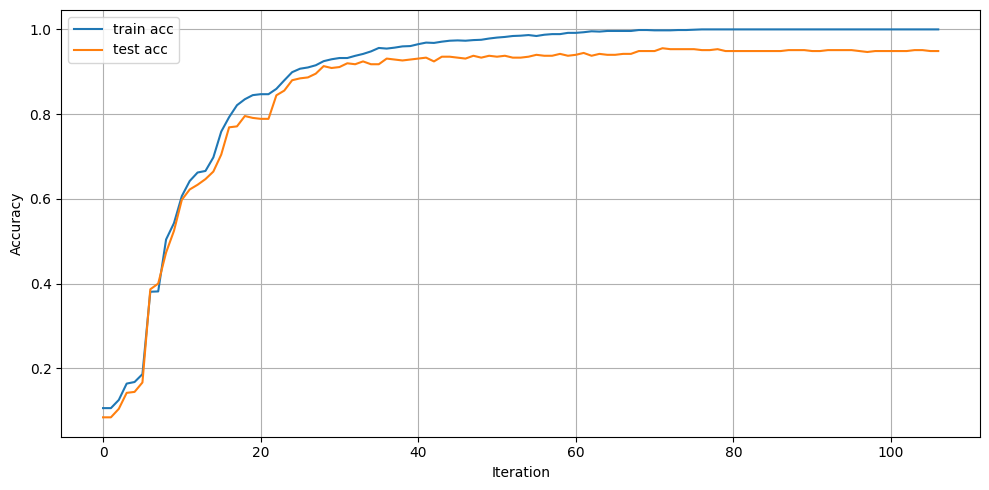

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(cb.train_acc, label="train acc")
ax.plot(cb.test_acc, label="test acc")
ax.set_xlabel("Iteration")
ax.set_ylabel("Accuracy")
ax.grid(True)
ax.legend()

fig.tight_layout()
plt.show()

### `Эксперименты с числом слоев (0.6 балла)`

Ясно, что из-за случайного начального приближения с каждым запуском обучения мы будем получать различное качество. Попробуем обучить нашу нейросеть с разным числом слоев несколько раз.

Заполните матрицы `accs_train` и `accs_test`. В позиции `[i, j]` должна стоять величина доли правильных ответов сети с $i+1$ полносвязными слоями при $j$-м запуске (все запуски идентичны).

In [ ]:
accs_train = np.zeros((5, 5))
accs_test = np.zeros((5, 5))

In [ ]:
### your code here
for i in range(5):
  for j in range(5):
    n_layers = i + 1
    network = make_network(input_size, hidden_layers_size, output_size, n_layers)

    weights = get_weights(network)
    res = minimize(compute_loss_grad, weights, args=[network, X_train, y_train],
                   method="L-BFGS-B", jac=True)
    set_weights(res["x"], network)

    train_pred = predict(network, X_train)
    test_pred = predict(network, X_test)

    accs_train[i][j] = np.mean(train_pred == y_train)
    accs_test[i][j] = np.mean(test_pred == y_test)

Построим боксплоты полученного качества (горизонтальная линия в каждом столбце — среднее, прямоугольник показывает разброс).

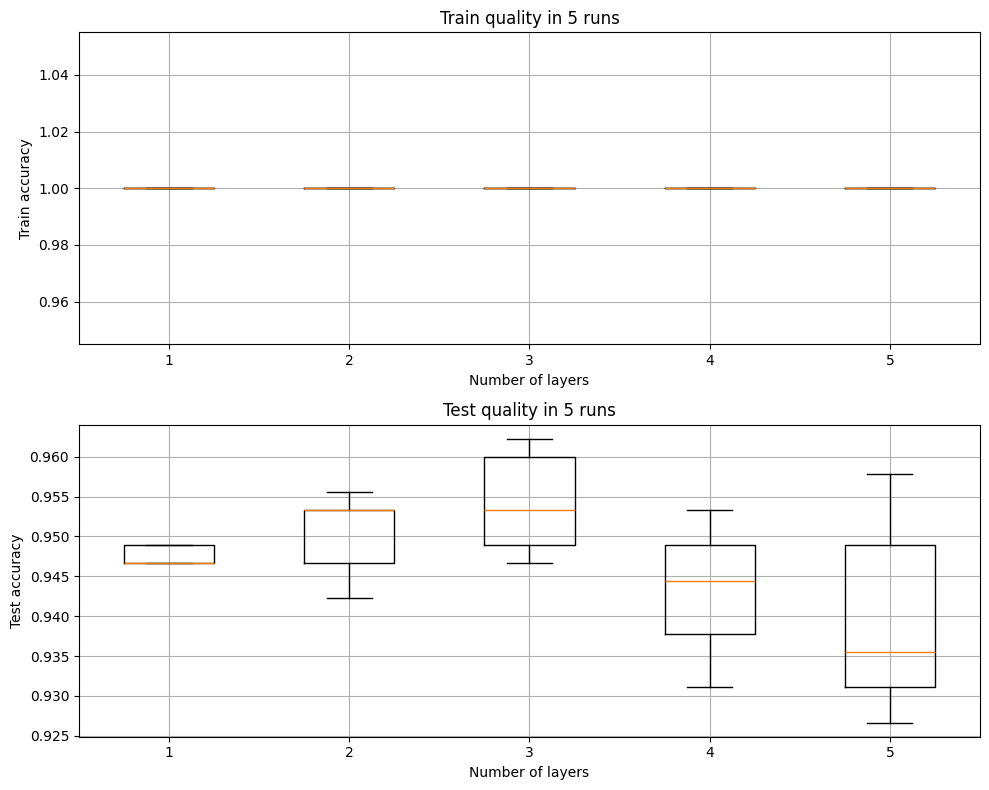

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].boxplot(accs_train.T, showfliers=False)
axes[1].boxplot(accs_test.T, showfliers=False)

axes[0].set_xlabel("Number of layers")
axes[1].set_xlabel("Number of layers")

axes[0].set_ylabel("Train accuracy")
axes[1].set_ylabel("Test accuracy")

axes[0].set_title("Train quality in 5 runs")
axes[1].set_title("Test quality in 5 runs")

axes[0].grid(True)
axes[1].grid(True)

fig.tight_layout()
plt.show()

Дайте развёрнутый ответ на вопросы (в этой же ячейке):
* Как изменяются качество на обучении и контроле и устойчивость процесса обучения при увеличении числа слоев?
* Можно ли сказать, что логистическая регрессия (линейная модель) дает качество хуже, чем нелинейная модель?

__Ответы:__

При увеличении числа полносвязных слоев качество на обучении не изменяется, модели полностью подстраиваются под обучающую выборку (Accuracy = **1.000**), а на контроле сначала возврастает, достигает порога и уменьшается. При 1 слое (линейная модель) Accuracy достигает в среднем **0.947**, разброс небольшой. Переходя к нелинейной модели (2-3 слой) качество заметно улучшается и Accuracy в среднем равно **0.953**, разброс при этом увеличивается, то есть Accuracy достигает до **0.963**. При дальшейшем увеличении глубины качество в среднем снижается, а разброс увеличивается. Таким образом в данном случае линейная модель дает более плохое качество, чем нелинейная, а устойчивость процесса постепенно снижается.

### `Эксперименты c различными инициализациями весов (0.6 балла)`

Как уже было сказано, начальная инициализация весов нейронной сети может сильно влиять на процесс ее обучения и, как следствие, на ее качество.

В этом пункте вам предлагается попробовать обучить несколько нейронных сетей с различными инициализациями слоев.

Для этого необходимо реализовать функцию, инициализирующую веса линейных слоёв нашей нейронной сети. Добавьте в функционал данного метода возможность инициализировать его веса с помощью инициализации Kaiming (используется, если в нейронной сети в качестве функций активации используется ReLU) и инициализации Xavier (используется, если в нейронной сети в качестве функций активации используется Tanh или Sigmoid):

In [37]:
def initialize_network(network, initialization):
    for layer in network:
        if isinstance(layer, Dense):
            input_units, output_units = layer.weights.shape
            if initialization == 'Kaiming':
                ### your code here
                layer.weights = np.random.randn(input_units, output_units) * np.sqrt(2 / input_size)
            elif initialization == 'Xavier':
                ### your code here
                layer.weights = np.random.randn(input_units, output_units) * np.sqrt(2 / (input_size + output_size))
            else:
                # Initialize weights with small random numbers from normal distribution.
                # In this case `initialization` represents a standard deviation
                # for normal distribution.
                layer.weights = np.random.randn(input_units, output_units) * initialization
            layer.biases = np.zeros_like(layer.biases)

            layer.params = [layer.weights, layer.biases]

Теперь попробуйте для каждой из 3 инициализаций обучить нейронную сеть несколько раз. Попробуйте проделать данную операцию при зафиксированном числе слоев равным 3, 4 и 5.

#### `3 слоя`

Зафиксируйте в сети число слоев равное трем.

Заполните матрицы `accs_train` и `accs_test`. В позиции `[i, j]` должна стоять величина доли правильных ответов сети при $j$-м запуске (все запуски идентичны) с инициализацией Kaiming при $i = 3$, с инициализацией Xavier при $i = 4$ и с инициализацией из нормального распределения с фиксированными параметрами при $0 \leqslant i \leqslant 2$ (попробуйте здесь 3 разных параметра для стандартного отклонения для нормального распределения, например: `1e-3`, `1e-2`, `1e-1`). Заметьте, что при большом числе слоев слишком низкое стандартное отклонение может не давать нейронной сети нормально обучиться.

In [ ]:
init_vars = [1e-3, 1e-2, 1e-1, 'Kaiming', 'Xavier']

In [ ]:
accs_train = np.zeros((5, 5))
accs_test = np.zeros((5, 5))

In [ ]:
### your code here
n_layers = 3
for i in range(5):
  for j in range(5):
    network = make_network(input_size, hidden_layers_size, output_size, n_layers)
    initialize_network(network, init_vars[i])

    weights = get_weights(network)
    res = minimize(compute_loss_grad, weights, args=[network, X_train, y_train],
                   method="L-BFGS-B", jac=True)
    set_weights(res["x"], network)

    train_pred = predict(network, X_train)
    test_pred = predict(network, X_test)

    accs_train[i][j] = np.mean(train_pred == y_train)
    accs_test[i][j] = np.mean(test_pred == y_test)

Построим боксплоты полученного качества (горизонтальная линия в каждом столбце — среднее, прямоугольник показывает разброс).

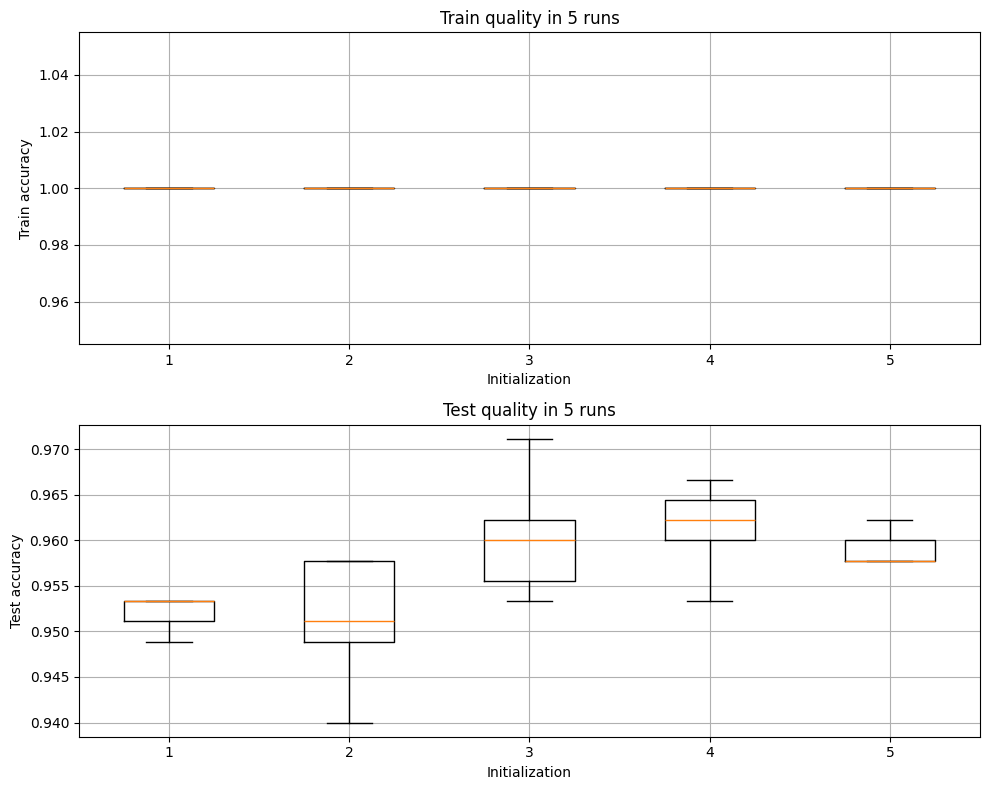

In [ ]:
init_vars_for_plot = [(x if isinstance(x, str) else fr"$\sigma = {x}$") for x in init_vars]

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].boxplot(accs_train.T, showfliers=False)
axes[1].boxplot(accs_test.T, showfliers=False)

axes[0].set_xlabel("Initialization")
axes[1].set_xlabel("Initialization")

axes[0].set_ylabel("Train accuracy")
axes[1].set_ylabel("Test accuracy")

axes[0].set_title("Train quality in 5 runs")
axes[1].set_title("Test quality in 5 runs")

axes[0].grid(True)
axes[1].grid(True)

fig.tight_layout()
plt.show()

#### `4 слоя`

Выполните тут тот же код, что и в предыдущем пункте, но только уже с 4 слоями в сети.

In [ ]:
init_vars = [5e-3, 1e-2, 1e-1, 'Kaiming', 'Xavier']

In [ ]:
accs_train = np.zeros((5, 5))
accs_test = np.zeros((5, 5))

In [ ]:
### your code here
n_layers = 4
for i in range(5):
  for j in range(5):
    network = make_network(input_size, hidden_layers_size, output_size, n_layers)
    initialize_network(network, init_vars[i])

    weights = get_weights(network)
    res = minimize(compute_loss_grad, weights, args=[network, X_train, y_train],
                   method="L-BFGS-B", jac=True)
    set_weights(res["x"], network)

    train_pred = predict(network, X_train)
    test_pred = predict(network, X_test)

    accs_train[i][j] = np.mean(train_pred == y_train)
    accs_test[i][j] = np.mean(test_pred == y_test)

Построим боксплоты полученного качества (горизонтальная линия в каждом столбце — среднее, прямоугольник показывает разброс).

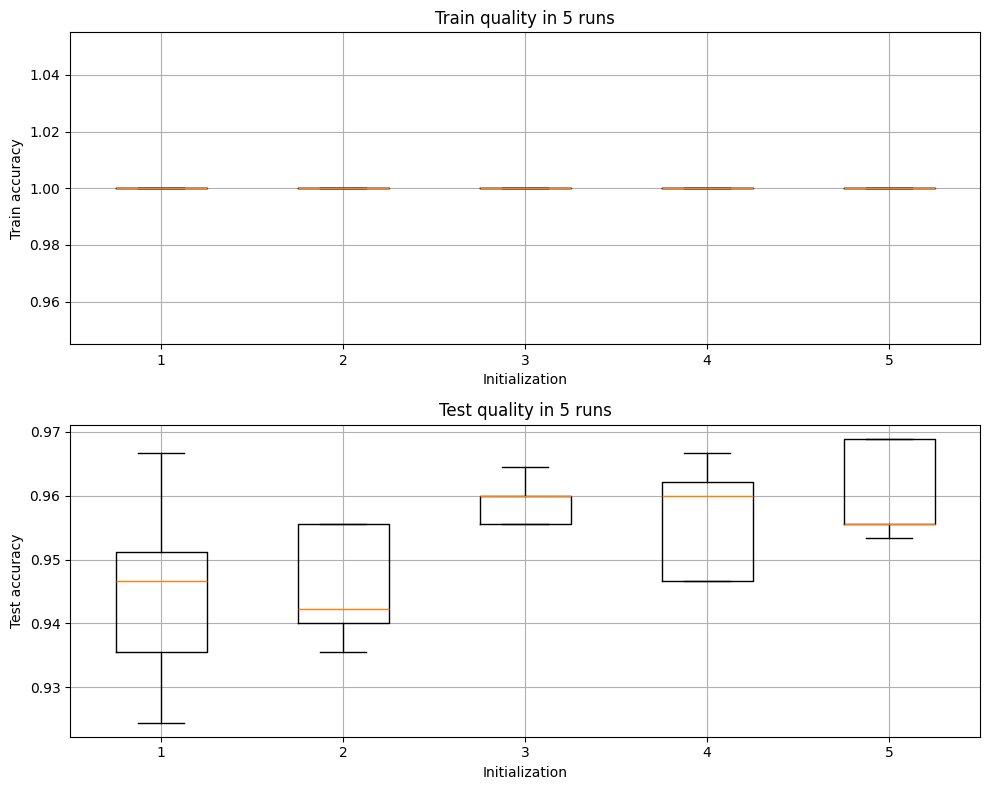

In [ ]:
init_vars_for_plot = [(x if isinstance(x, str) else fr"$\sigma = {x}$") for x in init_vars]

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].boxplot(accs_train.T, showfliers=False)
axes[1].boxplot(accs_test.T, showfliers=False)

axes[0].set_xlabel("Initialization")
axes[1].set_xlabel("Initialization")

axes[0].set_ylabel("Train accuracy")
axes[1].set_ylabel("Test accuracy")

axes[0].set_title("Train quality in 5 runs")
axes[1].set_title("Test quality in 5 runs")

axes[0].grid(True)
axes[1].grid(True)

fig.tight_layout()
plt.show()

#### `5 слоев`

Выполните тут тот же код, что и в предыдущем пункте, но только уже с 5 слоями в сети.

In [ ]:
init_vars = [1e-2, 1e-1, 1e0, 'Kaiming', 'Xavier']

In [ ]:
accs_train = np.zeros((5, 5))
accs_test = np.zeros((5, 5))

In [ ]:
### your code here
n_layers = 5
for i in range(5):
  for j in range(5):
    network = make_network(input_size, hidden_layers_size, output_size, n_layers)
    initialize_network(network, init_vars[i])

    weights = get_weights(network)
    res = minimize(compute_loss_grad, weights, args=[network, X_train, y_train],
                   method="L-BFGS-B", jac=True)
    set_weights(res["x"], network)

    train_pred = predict(network, X_train)
    test_pred = predict(network, X_test)

    accs_train[i][j] = np.mean(train_pred == y_train)
    accs_test[i][j] = np.mean(test_pred == y_test)

Построим боксплоты полученного качества (горизонтальная линия в каждом столбце — среднее, прямоугольник показывает разброс).

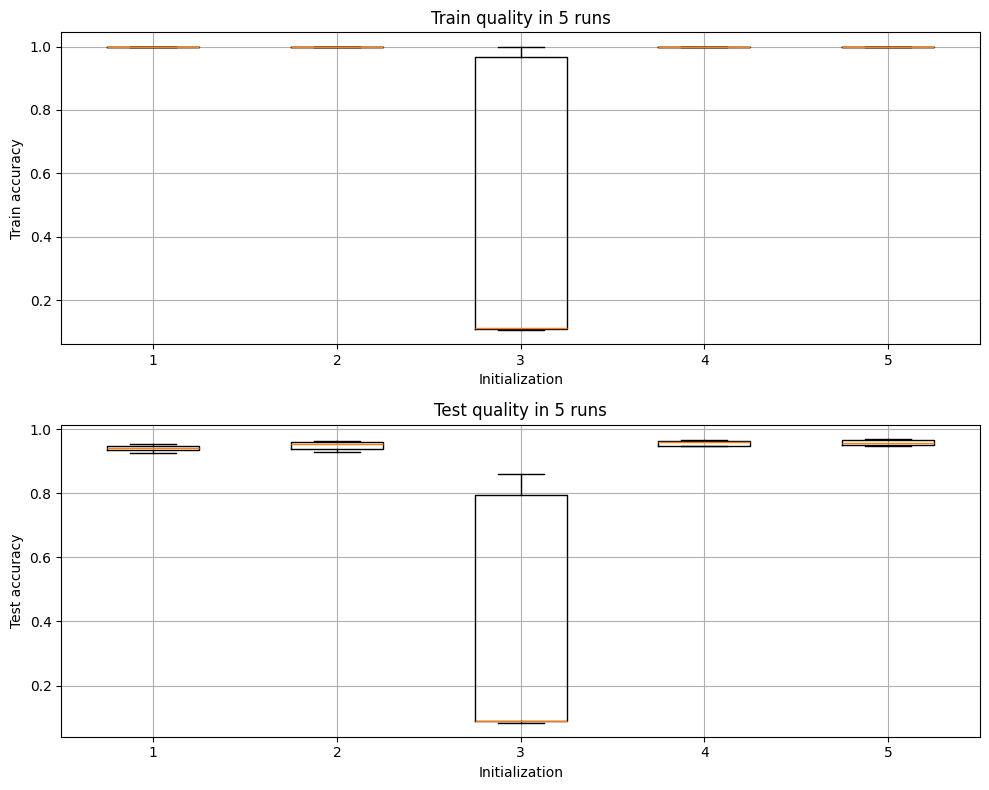

In [ ]:
init_vars_for_plot = [(x if isinstance(x, str) else fr"$\sigma = {x}$") for x in init_vars]

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].boxplot(accs_train.T, showfliers=False)
axes[1].boxplot(accs_test.T, showfliers=False)

axes[0].set_xlabel("Initialization")
axes[1].set_xlabel("Initialization")

axes[0].set_ylabel("Train accuracy")
axes[1].set_ylabel("Test accuracy")

axes[0].set_title("Train quality in 5 runs")
axes[1].set_title("Test quality in 5 runs")

axes[0].grid(True)
axes[1].grid(True)

fig.tight_layout()
plt.show()

Дайте развёрнутый ответ на вопросы (в этой же ячейке):
* Как отличаются качество на обучении и контроле и устойчивость процесса обучения при различных инициализациях?
* Какие инициализации помогают обучать более глубокие сети?

__Ответы:__

3 слоя. Все рассмотренные инициализации на обучающей выборке достигают Accuracy, равное **1.000**, то есть модели полностью подстраиваются под обучающую выборку. При этом на тестовой выборке результаты отличаются. Лучшее медианное качество получилось достичь при инициализациях 3 и 4, Accuracy равно **0.960** и **0.963** соответственно. Разброс с 1 по 3 инициализацию увеличивается, а с 3 по 5 уменьшается.

4 слоя. Все рассмотренные инициализации на обучающей выборке достигают Accuracy, равное **1.000**, то есть модели полностью подстраиваются под обучающую выборку. На тестовой выборке наилучшего медианного качества тоже достигают инициализации 3 и 4. Accuray равно около **0.960** в обоих случаях. Наибольший разброс на инициализации номер 1, в остальных случаях он примерно одинаковый.

5 слоев. Все рассмотренные инициализации на обучающей выборке кроме инициализации номер 3 достигают Accuracy, равное **1.0**, то есть модели полностью подстраиваются под обучающую выборку. На тестовой выборке эти честыре инициализации устойчивы и показывают высокое качество. Инициализация 3 и на тренировочной, и на тестовой выборках показывает очень низкое медианное качество и огромный разброс.

Таким образом, для более глубоких сетей больше всего подходят инициализации 4 и 5.

Теперь сравним скорость обучения при различных инициализациях. Создайте два списка списков `accs_test_on_iterations`, `accs_train_on_iterations` в каждом из которых в позиции `[i]` (см. описание `i` в предыдущем пункте) будет лежать список из значений `accuracy` на тестовой и обучающей выборках соотвественно, полученных во время обучения модели. Количество слоев в сети зафиксируйте равным 4.

In [ ]:
init_vars = [1e-3, 1e-2, 1e-1, 'Kaiming', 'Xavier']

In [ ]:
accs_test_on_iterations = []
accs_train_on_iterations = []

In [ ]:
### your code here
n_layers = 4
for i in range(5):
  network = make_network(input_size, hidden_layers_size, output_size, n_layers)
  initialize_network(network, init_vars[i])
  cb = Callback(network, X_train, y_train, X_test, y_test, print=False)

  weights = get_weights(network)
  cb.call(weights)
  res = minimize(compute_loss_grad, weights, args=[network, X_train, y_train],
                 method="L-BFGS-B", jac=True, callback=cb.call)
  set_weights(res["x"], network)

  train_pred = predict(network, X_train)
  test_pred = predict(network, X_test)

  accs_train_on_iterations.append(cb.train_acc)
  accs_test_on_iterations.append(cb.test_acc)

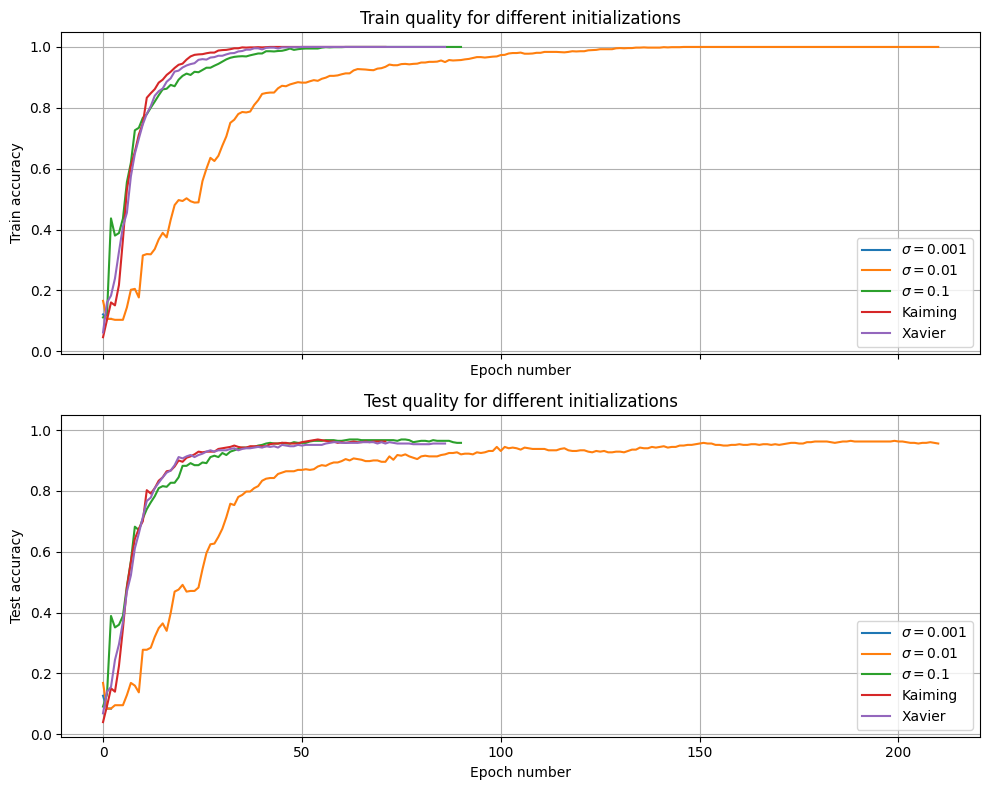

In [ ]:
init_vars_for_plot = [(x if isinstance(x, str) else fr"$\sigma = {x}$") for x in init_vars]

fig, ax = plt.subplots(2, 1, sharex=True, sharey=True,  figsize=(10, 8))

for idx, label in enumerate(init_vars_for_plot):
    ax[0].plot(accs_train_on_iterations[idx], label=label)
    ax[1].plot(accs_test_on_iterations[idx], label=label)

for idx, key in enumerate(["Train", "Test"]):
    ax[idx].set_title(f"{key} quality for different initializations")
    ax[idx].set_xlabel("Epoch number")
    ax[idx].set_ylabel(f"{key} accuracy")
    ax[idx].grid(True)
    ax[idx].legend()



fig.tight_layout()
plt.show()

Дайте развёрнутый ответ на вопросы (в этой же ячейке):
* Как меняется скорость cходимости в зависимости от выбранной инициализации?

__Ответы:__

Скорость сходимости для всех инициализаций, кроме σ = 0.01, схожи. На обучающей выборке большинство инициализаций сходится к **1.000** уже к эпохе 50, а инициализация σ = 0.01 сходится намного медленней и достикает метрику, равную **1.000**, только к эпохе 150. На тестовой выборке ситуация схожа, однако Accuracy = **1.000** не достигается, a останавливает свой рост при значении около **0.9**.

### `Эксперименты c различными функциями активации (0.6 балла)`

Проверим теперь, с какой функцией активации нейронная сеть будет обучаться лучше.

В этом пункте вам предлагается попробовать обучить несколько нейронных сетей с различными функциями активации.

Для этого нам нужно реализовать еще 2 слоя: для функций активации `Tanh` и `Sigmoid`.

In [38]:
class Tanh:
    """
    tanh(y) = (e^y - e^(-y)) / (e^y + e^(-y))
    Используйте функцию np.tanh для подсчета гиперболического тангенса.
    Вы можете сами реализовать подсчет tanh, но тогда вам нужно устойчиво его вычислять.
    """
    def __init__(self):
        self.params = [] # Tanh has no parameters

    def forward(self, input):
        """
        Apply elementwise Tanh to [batch, num_units] matrix
        """
        ### your code here
        self.input = input
        return np.tanh(input)

    def backward(self, grad_output):
        """
        Compute gradient of loss w.r.t. Tanh input
        grad_output shape: [batch, num_units]
        output 1 shape: [batch, num_units]
        output 2: []
        """
        ### your code here
        grad_input = grad_output * (1 - np.tanh(self.input) ** 2)
        return grad_input, []


    def __repr__(self):
        return 'Tanh()'

In [39]:
from scipy.special import expit

class Sigmoid:
    """
    sigmoid(y) = 1 / (1 + e^(-y))
    Используйте функцию expit для подсчета сигмоиды.
    Вы можете сами реализовать подсчет сигмоиды, но тогда вам нужно устойчиво ее вычислять.
    """
    def __init__(self):
        self.params = [] # Sigmoid has no parameters

    def forward(self, input):
        """
        Apply elementwise Sigmoid to [batch, num_units] matrix
        """
        ### your code here
        self.input = input
        return expit(input)

    def backward(self, grad_output):
        """
        Compute gradient of loss w.r.t. Sigmoid input
        grad_output shape: [batch, num_units]
        output 1 shape: [batch, num_units]
        output 2: []
        """
        ### your code here
        grad_input = grad_output * expit(self.input) * expit(-self.input)
        return grad_input, []

    def __repr__(self):
        return 'Sigmoid()'

Теперь попробуйте для каждой из 3 функций активации обучить нейронную сеть несколько раз. Число слоев зафиксируйте равным 3. В случае `Tanh` и `Sigmoid` используйте инициализацию `Xavier`, а в случае `ReLU` используйте инициализацию `Kaiming`.

Заполните матрицы `accs_train` и `accs_test`. В позиции `[i, j]` должна стоять величина доли правильных ответов сети при $j$-м запуске (все запуски идентичны) с функцией активации $ReLU$ при $i = 0$, с функцией активации $Tanh$ при $i = 1$ и с функцией активации $Sigmoid$ при $i = 2$.

In [ ]:
act_func_vars = ['Tanh', 'Sigmoid', 'ReLU']
init_for_act_funcs = ['Xavier', 'Xavier', 'Kaiming']

In [ ]:
accs_train = np.zeros((3, 5))
accs_test = np.zeros((3, 5))

In [ ]:
### your code here
n_layers = 3
for i in range(3):
  for j in range(5):
    activation_class = act_func_vars[i]

    if activation_class == 'Tanh':
      network = make_network(input_size, hidden_layers_size, output_size,
                            n_layers, activation_class=Tanh)
    elif activation_class == 'Sigmoid':
      network = make_network(input_size, hidden_layers_size, output_size,
                            n_layers, activation_class=Sigmoid)
    elif activation_class == 'ReLU':
      network = make_network(input_size, hidden_layers_size, output_size,
                            n_layers, activation_class=ReLU)

    initialize_network(network, init_for_act_funcs[i])
    weights = get_weights(network)
    res = minimize(compute_loss_grad, weights, args=[network, X_train, y_train],
                  method="L-BFGS-B", jac=True)
    set_weights(res["x"], network)

    train_pred = predict(network, X_train)
    test_pred = predict(network, X_test)

    accs_train[i][j] = np.mean(train_pred == y_train)
    accs_test[i][j] = np.mean(test_pred == y_test)

Построим боксплоты полученного качества (горизонтальная линия в каждом столбце — среднее, прямоугольник показывает разброс).

/tmp/ipykernel_485/3446252315.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot(accs_train.T, labels=act_func_vars, showfliers=False)
/tmp/ipykernel_485/3446252315.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(accs_test.T, labels=act_func_vars, showfliers=False)


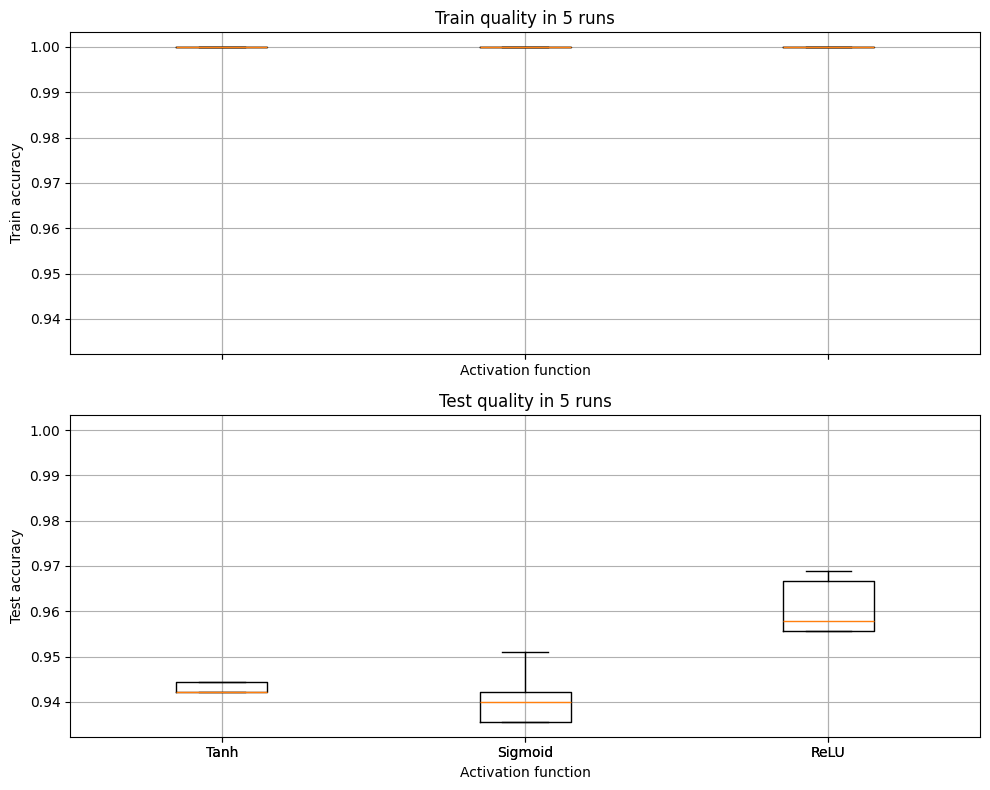

In [ ]:
fig, ax = plt.subplots(2, 1, sharex=True, sharey=True,  figsize=(10, 8))

ax[0].boxplot(accs_train.T, labels=act_func_vars, showfliers=False)
ax[1].boxplot(accs_test.T, labels=act_func_vars, showfliers=False)

ax[0].set_title("Train quality in 5 runs")
ax[1].set_title("Test quality in 5 runs")

ax[0].set_xlabel("Activation function")
ax[1].set_xlabel("Activation function")

ax[0].set_ylabel("Train accuracy")
ax[1].set_ylabel("Test accuracy")

ax[0].grid(True)
ax[1].grid(True)

fig.tight_layout()
plt.show()

Дайте развёрнутый ответ на вопросы (в этой же ячейке):
* Как отличаются качество на обучении и контроле и устойчивость процесса обучения при различных функциях активации?

__Ответы:__

На обучающей выборке во всех случаях достигается Accuracy, равное **1.000**, то есть модели полностью подстраиваются под обучающую выборку. Все три функции активации помогают достичь хорошего качества на тестовой выборке. Функция `Tanh` имеет маленький разброс и медианное значение около **0.943**. Функция `Sigmoid` имеет разброс побольше с выбросами, достигающими Accuracy **0.950**, медианное значение при этом равно **0.940**. Функция `ReLU` имеет сравнительно самое высокое качество из всех. Устойчивость процесса примерно такая же, как у функции `Sigmoid`, медианное значение Accuracy для `ReLU` достигает около **0.958**, а выбросы до **0.970**.

\* Несколько фрагментов кода в задании написаны на основе материалов [курса по глубинному обучению на ФКН НИУ ВШЭ](https://www.hse.ru/ba/ami/courses/205504078.html)

### `Реализация метода оптимизации (1.4 балла)`

В этой части задания реализуйте метод оптимизации SGD + momentum. Упрощённая версия более общего алгоритма [отсюда](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html):

$$
\begin{aligned}
    &\rule{70mm}{0.4pt}                                                             \\
    &\textbf{input}      : \gamma \text{ (lr)}, \: \theta_0 \text{ (params)}, \: X \text{ (data)},       \\
    &\hspace{13mm} \: f(\theta) \text{ (objective)}, \:\mu \text{ (momentum)}       \\[-1.ex]
    &\rule{70mm}{0.4pt}                                                             \\
    &\textbf{for} \: t=1 \: \textbf{to} \: \ldots \: \textbf{do}                    \\
    &\hspace{5mm}\mathcal{X} \leftarrow \texttt{list\_of\_random\_batches}(X)\\
    &\hspace{5mm}\textbf{for} \: i=1 \: \textbf{to} \: \ldots \: \textbf{do}                    \\
    &\hspace{10mm}g_t\leftarrow   \nabla_{\theta} f_t (\theta_{t-1},\mathcal{X}_i)      \\
    &\hspace{10mm}\textbf{if} \: \mu \neq 0                                          \\
    &\hspace{15mm}\textbf{if} \: t > 1                                              \\
    &\hspace{20mm} \textbf{b}_t \leftarrow \mu \textbf{b}_{t-1} + g_t               \\
    &\hspace{15mm}\textbf{else}                                                     \\
    &\hspace{20mm} \textbf{b}_t \leftarrow g_t                                      \\
    &\hspace{15mm} g_t  \leftarrow  \textbf{b}_t                                     \\
    &\hspace{10mm}\theta_t \leftarrow \theta_{t-1} - \gamma g_t                      \\[-1.ex]
    &\rule{70mm}{0.4pt}                                                             \\[-1.ex]
    &\bf{return} \:  \theta_t                                                       \\[-1.ex]
    &\rule{70mm}{0.4pt}                                                             \\[-1.ex]
\end{aligned}
$$

Проще всего будет написать `custom minimizer` (смотри [документацию scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html)).

In [40]:
from scipy.optimize import OptimizeResult


def SGD(fun, x0, args, **kwargs) -> OptimizeResult:
    callback = kwargs['callback']   # feed weights from each iteration to update network and log metrics
    mu = kwargs['momentum']
    n_iter = kwargs['n_iter']
    gamma = kwargs['lr']
    jac = kwargs['jac']
    batch_size = kwargs['batch_size']

    net, X, y = args

    # your code is here
    weights = np.array(x0, dtype=float, copy=True)
    momentum = np.zeros_like(weights)
    n_samples = X.shape[0]

    for _ in range(n_iter):
      indicies = np.random.permutation(n_samples)
      for i in range(0, n_samples, batch_size):
        batch_indicies = indicies[i:i + batch_size]
        X_batch = X[batch_indicies]
        y_batch = y[batch_indicies]

        loss, grad = fun(weights, (net, X_batch, y_batch))
        momentum = mu * momentum + grad
        weights = weights - gamma * momentum

      if callback is not None:
        callback(weights)

    return OptimizeResult(x=weights, fun=loss, success=True, nit=n_iter)

**Задание 1. (0.5 балла)** Продемонстрируйте правильную работу метода оптимизации, получив `test_accuracy>=0.9`.

In [41]:
# your code is here
n_layers = 3

network = make_network(input_size, hidden_layers_size, output_size, n_layers)
initialize_network(network, 'Kaiming')
weights = get_weights(network)

cb = Callback(network, X_train, y_train, X_test, y_test)
res = SGD(compute_loss_grad, weights, args=(network, X_train, y_train),
          callback=cb.call, momentum=0.9, n_iter=20, lr=1e-2, jac=True, batch_size=64)

set_weights(res['x'], network)

pred = predict(network, X_test)
test_accuracy = np.mean(pred == y_test)

print(f'Test Accuracy: {test_accuracy:.3f}')

Test Accuracy: 0.962


**Задание 2. (0.8 балла)** Сравните три алгоритма:
1. LBFGS-B
2. SGD
3. SGD + momentum

Для этого одновременно переберите следующие гиперпараметры:
- значения `lr` на отрезке `[1e-3, 1e-1]` по логарифмической сетке
- два значения `momentum`: `0` и `0.9`
- значения `batch_size`: `8` и `32`

В каждом запуске сохраняйте три метрики: итоговое accuracy на тесте и на трейне и время обучения.

Для каждого из трёх алгоритмов выберите лучшие `lr` и `batch_size` по `test_accuracy`. Постройте для них кривые обучения (пример ниже). Сделайте выводы.

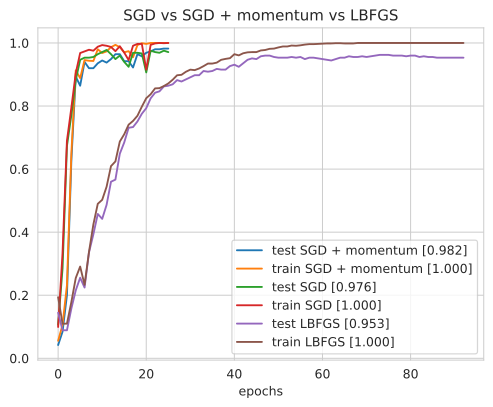

In [62]:
# your code is here

import time

# --------------- LBFGS-B ---------------

network_lbfgsb = make_network(input_size, hidden_layers_size, output_size, n_layers)
initialize_network(network_lbfgsb, 'Kaiming')
weights = get_weights(network_lbfgsb)

cb_lbfgsb = Callback(network_lbfgsb, X_train, y_train, X_test, y_test)

start = time.time()
res_lbfgsb = minimize(compute_loss_grad, weights, args=[network_lbfgsb, X_train, y_train],
                      method="L-BFGS-B", jac=True, callback=cb_lbfgsb.call)
time_lbfgsb = time.time() - start

set_weights(res_lbfgsb['x'], network_lbfgsb)

train_acc_lbfgsb = cb_lbfgsb.train_acc
test_acc_lbfgsb = cb_lbfgsb.test_acc

train_pred_lbfgsb = predict(network_lbfgsb, X_train)
test_pred_lbfgsb = predict(network_lbfgsb, X_test)

train_accuracy_lbfgsb = np.mean(train_pred_lbfgsb == y_train)
test_accuracy_lbfgsb = np.mean(test_pred_lbfgsb == y_test)

print(f'Accuracy (Train / Test): {train_accuracy_lbfgsb:.3f} / {test_accuracy_lbfgsb:.3f}')
print(f'Training time LBFGS-B  : {time_lbfgsb:.3f}')

# ---------------------------------------

Accuracy (Train / Test): 1.000 / 0.967
Training time LBFGS-B  : 3.291


In [59]:
# your code is here

# ----------------- SGD -----------------

learning_rates = np.logspace(-3, -1, 3)
batch_sizes = [8, 32]
sgd_results = []

for lr in learning_rates:
  for batch_size in batch_sizes:
    network_sgd = make_network(input_size, hidden_layers_size, output_size, n_layers)
    initialize_network(network_sgd, 'Kaiming')
    weights = get_weights(network_sgd)

    cb_sgd = Callback(network_sgd, X_train, y_train, X_test, y_test)

    start = time.time()
    res_sgd = SGD(compute_loss_grad, weights, args=[network_sgd, X_train, y_train],
          callback=cb_sgd.call, momentum=0, n_iter=30, lr=lr, jac=True, batch_size=batch_size)
    time_sgd = time.time() - start

    set_weights(res_sgd['x'], network_sgd)

    train_pred_sgd = predict(network_sgd, X_train)
    test_pred_sgd = predict(network_sgd, X_test)

    train_accuracy_sgd = np.mean(train_pred_sgd == y_train)
    test_accuracy_sgd = np.mean(test_pred_sgd == y_test)

    sgd_results.append({'lr': lr, 'batch_size': batch_size, 'train_accuracy': train_accuracy_sgd,
                        'test_accuracy': test_accuracy_sgd, 'time': time_sgd,
                        'train_curve': cb_sgd.train_acc, 'test_curve': cb_sgd.test_acc})

    print(f'lr={lr}, batch_size={batch_size}')
    print(f'Accuracy (Train / Test): {train_accuracy_sgd:.3f} / {test_accuracy_sgd:.3f}')
    print(f'Training time SGD  : {time_sgd:.3f}\n')

best_sgd = max(sgd_results, key=lambda x: x['test_accuracy'])

# ---------------------------------------

lr=0.001, batch_size=8
Accuracy (Train / Test): 0.976 / 0.951
Training time SGD  : 76.360

lr=0.001, batch_size=32
Accuracy (Train / Test): 0.884 / 0.847
Training time SGD  : 20.410

lr=0.01, batch_size=8
Accuracy (Train / Test): 1.000 / 0.964
Training time SGD  : 62.007

lr=0.01, batch_size=32
Accuracy (Train / Test): 0.994 / 0.956
Training time SGD  : 16.925

lr=0.1, batch_size=8
Accuracy (Train / Test): 0.106 / 0.084
Training time SGD  : 62.330

lr=0.1, batch_size=32
Accuracy (Train / Test): 0.105 / 0.082
Training time SGD  : 17.063



In [60]:
print(f'lr={best_sgd['lr']}, batch_size={best_sgd['batch_size']}')
print(f'Accuracy (Train / Test): {best_sgd['train_accuracy']:.3f} / {best_sgd['test_accuracy']:.3f}')
print(f'Training time SGD  : {best_sgd['time']:.3f}\n')

lr=0.01, batch_size=8
Accuracy (Train / Test): 1.000 / 0.964
Training time SGD  : 62.007



In [46]:
# your code is here

# ----------- SGD + momentum ------------

learning_rates = np.logspace(-3, -1, 3)
batch_sizes = [8, 32]
sgd09_results = []

for lr in learning_rates:
  for batch_size in batch_sizes:
    network_sgd09 = make_network(input_size, hidden_layers_size, output_size, n_layers)
    initialize_network(network_sgd09, 'Kaiming')
    weights = get_weights(network_sgd09)

    cb_sgd09 = Callback(network_sgd09, X_train, y_train, X_test, y_test)

    start = time.time()
    res_sgd09 = SGD(compute_loss_grad, weights, args=[network_sgd09, X_train, y_train],
          callback=cb_sgd09.call, momentum=0.9, n_iter=25, lr=lr, jac=True, batch_size=batch_size)
    time_sgd09 = time.time() - start

    set_weights(res_sgd09['x'], network_sgd09)

    train_pred_sgd09 = predict(network_sgd09, X_train)
    test_pred_sgd09 = predict(network_sgd09, X_test)

    train_accuracy_sgd09 = np.mean(train_pred_sgd09 == y_train)
    test_accuracy_sgd09 = np.mean(test_pred_sgd09 == y_test)

    sgd09_results.append({'lr': lr, 'batch_size': batch_size, 'train_accuracy': train_accuracy_sgd09,
                        'test_accuracy': test_accuracy_sgd09, 'time': time_sgd09,
                        'train_curve': cb_sgd09.train_acc, 'test_curve': cb_sgd09.test_acc})

    print(f'lr={lr}, batch_size={batch_size}')
    print(f'Accuracy (Train / Test)     : {train_accuracy_sgd09:.3f} / {test_accuracy_sgd09:.3f}')
    print(f'Training time SGD + momentum: {time_sgd09:.3f}\n')

best_sgd09 = max(sgd09_results, key=lambda x: x['test_accuracy'])

# ---------------------------------------

lr=0.001, batch_size=8
Accuracy (Train / Test)     : 1.000 / 0.967
Training time SGD + momentum: 70.230

lr=0.001, batch_size=32
Accuracy (Train / Test)     : 0.995 / 0.962
Training time SGD + momentum: 18.767

lr=0.01, batch_size=8
Accuracy (Train / Test)     : 0.106 / 0.084
Training time SGD + momentum: 89.629

lr=0.01, batch_size=32
Accuracy (Train / Test)     : 1.000 / 0.969
Training time SGD + momentum: 27.066

lr=0.1, batch_size=8
Accuracy (Train / Test)     : 0.106 / 0.084
Training time SGD + momentum: 72.624

lr=0.1, batch_size=32
Accuracy (Train / Test)     : 0.099 / 0.107
Training time SGD + momentum: 15.478



In [47]:
print(f'lr={best_sgd09['lr']}, batch_size={best_sgd09['batch_size']}')
print(f'Accuracy (Train / Test)     : {best_sgd09['train_accuracy']:.3f} / {best_sgd09['test_accuracy']:.3f}')
print(f'Training time SGD + momentum: {best_sgd09['time']:.3f}\n')

lr=0.01, batch_size=32
Accuracy (Train / Test)     : 1.000 / 0.969
Training time SGD + momentum: 27.066



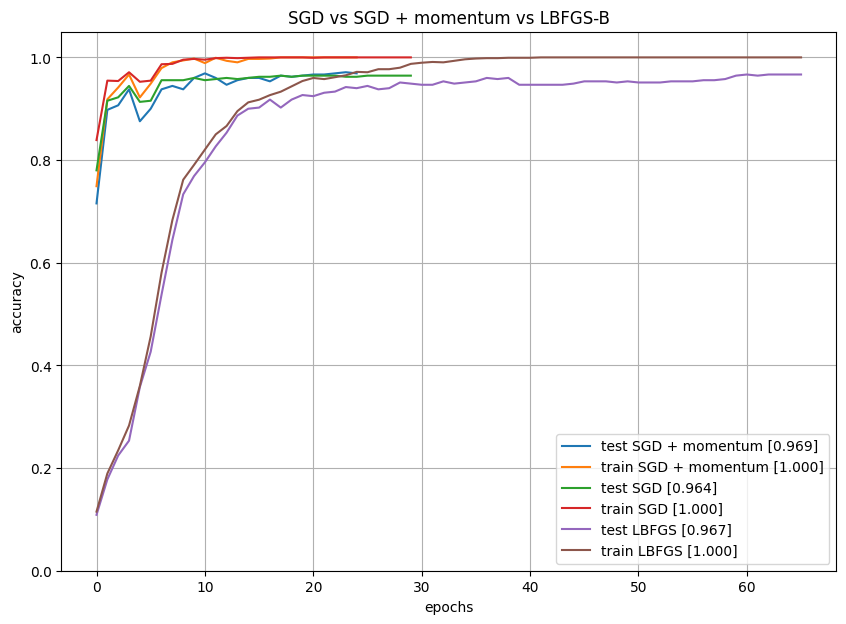

In [63]:
plt.figure(figsize=(10, 7))

plt.plot(best_sgd09['test_curve'], label=f"test SGD + momentum [{best_sgd09['test_accuracy']:.3f}]")
plt.plot(best_sgd09['train_curve'], label=f"train SGD + momentum [{best_sgd09['train_accuracy']:.3f}]")

plt.plot(best_sgd['test_curve'], label=f"test SGD [{best_sgd['test_accuracy']:.3f}]")
plt.plot(best_sgd['train_curve'], label=f"train SGD [{best_sgd['train_accuracy']:.3f}]")

plt.plot(test_acc_lbfgsb, label=f"test LBFGS [{test_accuracy_lbfgsb:.3f}]")
plt.plot(train_acc_lbfgsb, label=f"train LBFGS [{train_accuracy_lbfgsb:.3f}]")

plt.title('SGD vs SGD + momentum vs LBFGS-B')
plt.xlabel('epochs')
plt.ylabel('accuracy')

plt.ylim(0, 1.05)
plt.grid()
plt.legend()

plt.show()

**Выводы:**

`SGD` и `SGD + momentum` показали схожий результат. Они сходятся уже к 15 эпохе, а `SGD + momentum` достигает к тому же наиболее точный результат на тестовой выборке Accuracy = **0.969**. Метод `LBFGS-B` сходится заметно медленней, к 30 эпохе. При этом на тестовой выборке достигается качество **0.967**, близкое к качеству модели `SGD` (**0.964**).

**Задание 3. (0.1 балла)** Для отобранных в прошлом задании трёх алгоритмов ответье на вопрос: как меняются запуски для двух значений `batch_size`.

**Ответ:**

При `batch_size` = 8 время обучения намного больше, чем при `batch_size` = 32. Это объясняется тем, что при меньшем размере батча оптимизатор выполняет большее количество шагов обновления весов и чаще вычисляет градиент, что требует значительно больше времени.

## `Бонусная часть`

### `Реализация метода оптимизации (1 балл)`

Реализуйте метод оптимизации Adam и сравните его работу с SGD + momentum, проведя эксперимент, как в задании 2 (перебор гиперпараметров + кривые обучения).

In [42]:
def Adam(fun, x0, args, **kwargs) -> OptimizeResult:
    callback = kwargs['callback']
    n_iter = kwargs['n_iter']
    gamma = kwargs['lr']
    batch_size = kwargs['batch_size']

    beta1 = kwargs.get('beta1', 0.9)
    beta2 = kwargs.get('beta2', 0.999)
    eps = kwargs.get('eps', 1e-8)

    net, X, y = args

    weights = np.array(x0, dtype=float, copy=True)
    m, v = np.zeros_like(weights), np.zeros_like(weights)
    n_samples = X.shape[0]
    t = 0

    for _ in range(n_iter):
      indicies = np.random.permutation(n_samples)
      for i in range(0, n_samples, batch_size):
        batch_indicies = indicies[i:i + batch_size]
        X_batch = X[batch_indicies]
        y_batch = y[batch_indicies]

        loss, grad = fun(weights, (net, X_batch, y_batch))
        t += 1

        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad ** 2)
        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)

        weights = weights - gamma * m_hat / (np.sqrt(v_hat) + eps)

      if callback is not None:
        callback(weights)

    return OptimizeResult(x=weights, fun=loss, success=True, nit=n_iter)

In [53]:
# your code is here

# ---------------- Adam -----------------

learning_rates = np.logspace(-3, -1, 3)
batch_sizes = [8, 32]
adam_results = []

for lr in learning_rates:
  for batch_size in batch_sizes:
    network_adam = make_network(input_size, hidden_layers_size, output_size, n_layers)
    initialize_network(network_adam, 'Kaiming')
    weights = get_weights(network_adam)

    cb_adam = Callback(network_adam, X_train, y_train, X_test, y_test)

    start = time.time()
    res_adam = Adam(compute_loss_grad, weights, args=[network_adam, X_train, y_train],
          callback=cb_adam.call, n_iter=25, lr=lr, batch_size=batch_size)
    time_adam = time.time() - start

    set_weights(res_adam['x'], network_adam)

    train_pred_adam = predict(network_adam, X_train)
    test_pred_adam = predict(network_adam, X_test)

    train_accuracy_adam = np.mean(train_pred_adam == y_train)
    test_accuracy_adam = np.mean(test_pred_adam == y_test)

    adam_results.append({'lr': lr, 'batch_size': batch_size, 'train_accuracy': train_accuracy_adam,
                        'test_accuracy': test_accuracy_adam, 'time': time_adam,
                        'train_curve': cb_adam.train_acc, 'test_curve': cb_adam.test_acc})

    print(f'lr={lr}, batch_size={batch_size}')
    print(f'Accuracy (Train / Test): {train_accuracy_adam:.3f} / {test_accuracy_adam:.3f}')
    print(f'Training time Adam     : {time_adam:.3f}\n')

best_adam = max(adam_results, key=lambda x: x['test_accuracy'])

# ---------------------------------------

lr=0.001, batch_size=8
Accuracy (Train / Test): 1.000 / 0.976
Training time Adam     : 52.992

lr=0.001, batch_size=32
Accuracy (Train / Test): 0.999 / 0.960
Training time Adam     : 14.016

lr=0.01, batch_size=8
Accuracy (Train / Test): 0.978 / 0.938
Training time Adam     : 50.391

lr=0.01, batch_size=32
Accuracy (Train / Test): 1.000 / 0.978
Training time Adam     : 13.978

lr=0.1, batch_size=8
Accuracy (Train / Test): 0.099 / 0.098
Training time Adam     : 50.351

lr=0.1, batch_size=32
Accuracy (Train / Test): 0.099 / 0.098
Training time Adam     : 14.101



In [54]:
print(f'lr={best_adam['lr']}, batch_size={best_adam['batch_size']}')
print(f'Accuracy (Train / Test): {best_adam['train_accuracy']:.3f} / {best_adam['test_accuracy']:.3f}')
print(f'Training time Adam     : {best_adam['time']:.3f}\n')

lr=0.01, batch_size=32
Accuracy (Train / Test): 1.000 / 0.978
Training time Adam     : 13.978



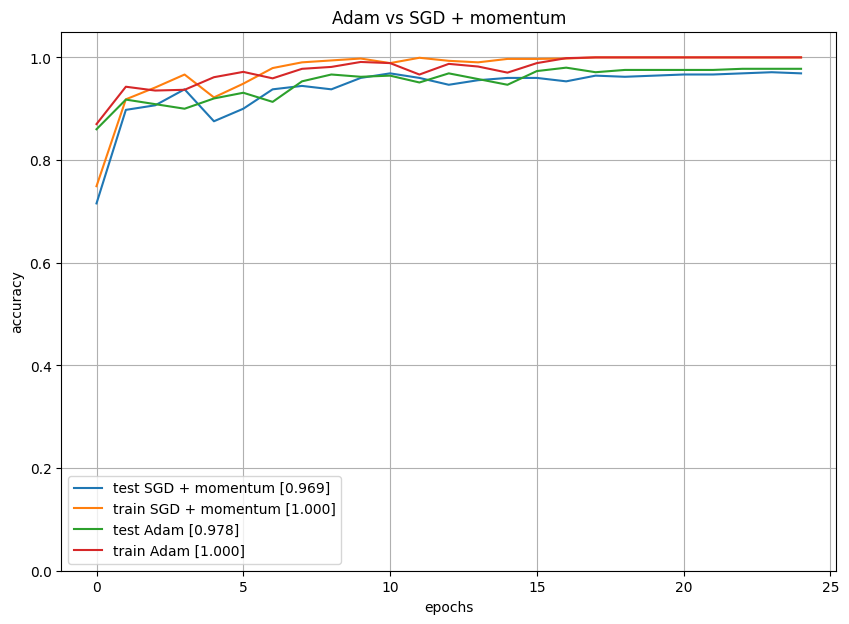

In [55]:
plt.figure(figsize=(10, 7))

plt.plot(best_sgd09['test_curve'], label=f"test SGD + momentum [{best_sgd09['test_accuracy']:.3f}]")
plt.plot(best_sgd09['train_curve'], label=f"train SGD + momentum [{best_sgd09['train_accuracy']:.3f}]")

plt.plot(best_adam['test_curve'], label=f"test Adam [{best_adam['test_accuracy']:.3f}]")
plt.plot(best_adam['train_curve'], label=f"train Adam [{best_adam['train_accuracy']:.3f}]")

plt.title('Adam vs SGD + momentum')
plt.xlabel('epochs')
plt.ylabel('accuracy')

plt.ylim(0, 1.05)
plt.grid()
plt.legend()

plt.show()

**Выводы:**

`Adam`, как и `SGD + momentum` имеет быструю сходимость. На тестовой выборке `Adam` имеет чуть более хорошее качество, чем у других моделей, Accuracy достигает **0.978**. При этом `Adam` также имеет намного более быстрое время обучения, чем модели с `SGD`: Training time (`Adam`) = **13.978**, Training time (`SGD + momentum`) = **27.066**, Training time (`SGD`) = **62.007**, Training time (`LBFGS-B`) = **5.341**.

### `Dropout (1 балл)`

Реализуйте слой Dropout. Сравните обучение сети из большого числа слоёв при использовании Dropout и без его использования (предварительно подберите адекватный параметр $p$). Сделайте выводы.

In [77]:
class Dropout:
  def __init__(self, p=0.5):
    self.p = p
    self.params = []
    self.training = True
    self.mask = None

  def forward(self, input):
    if not self.training:
      return input
    self.mask = (np.random.rand(*input.shape) >= self.p) / (1 - self.p)
    return input * self.mask

  def backward(self, grad_output):
    if not self.training:
      return grad_output
    return grad_output * self.mask, []

  def __repr__(self):
    return f'Dropout(p={self.p})'

In [78]:
def train_mode(network):
  for layer in network:
    if isinstance(layer, Dropout):
      layer.training = True

def eval_mode(network):
  for layer in network:
    if isinstance(layer, Dropout):
      layer.training = False

In [79]:
def compute_loss_grad(weights, args):
    network, X, y = args

    set_weights(weights, network)
    train_mode(network)
    activations = forward(network, X)

    loss = NLL(activations, y)
    grad_output = grad_NLL(activations, y)

    all_grads = []
    for layer in reversed(network):
      grad_output, layer_grad = layer.backward(grad_output)
      all_grads.append(layer_grad)

    all_grads.reverse()
    grads = np.r_[tuple(
        grad.ravel()
        for layer_grads in all_grads
        for grad in layer_grads
    )]

    return loss, grads

def predict(network, X):
    eval_mode(network)
    activations = forward(network, X)
    return np.argmax(activations, axis=1)

In [80]:
def make_network(input_size, hidden_layers_size, output_size, n_layers=3,
                 activation_class=ReLU, use_dropout=False, p=0.5):

    network = []

    for layer_idx in range(n_layers):
        layer_in = input_size if layer_idx == 0 else hidden_layers_size
        layer_out = output_size if layer_idx == n_layers - 1 else hidden_layers_size

        network.append(Dense(layer_in, layer_out))

        if layer_idx != n_layers - 1:
            network.append(activation_class())
            if use_dropout:
              network.append(Dropout(p=p))

    network.append(LogSoftmax())

    return network

In [81]:
p_values = [0.1, 0.3, 0.5]
results = []

for p in p_values:
  network = make_network(input_size, hidden_layers_size, output_size,
                         n_layers=10, use_dropout=True, p=p)

  initialize_network(network, 'Kaiming')
  weights = get_weights(network)

  cb = Callback(network, X_train, y_train, X_test, y_test)
  res = Adam(compute_loss_grad, weights, args=[network, X_train, y_train],
             callback=cb.call, n_iter=60, lr=0.001, batch_size=32)
  set_weights(res['x'], network)

  train_pred = predict(network, X_train)
  test_pred = predict(network, X_test)

  train_acc = np.mean(train_pred == y_train)
  test_acc = np.mean(test_pred == y_test)

  results.append({'p': p, 'train_accuracy': train_acc, 'test_accuracy': test_acc,
                  'train_curve': cb.train_acc, 'test_curve': cb.test_acc})

best = max(results, key=lambda x: x['test_accuracy'])
print(best['p'])

0.1


In [83]:
network_adam = make_network(input_size, hidden_layers_size, output_size, n_layers=10)
initialize_network(network_adam, 'Kaiming')
weights = get_weights(network_adam)

cb_adam = Callback(network_adam, X_train, y_train, X_test, y_test)
res_adam = Adam(compute_loss_grad, weights, args=[network_adam, X_train, y_train],
                callback=cb_adam.call, n_iter=60, lr=0.01, batch_size=32)
set_weights(res_adam['x'], network_adam)

train_pred_adam = predict(network_adam, X_train)
test_pred_adam = predict(network_adam, X_test)

train_accuracy_adam = np.mean(train_pred_adam == y_train)
test_accuracy_adam = np.mean(test_pred_adam == y_test)

best_adam = ({'train_accuracy': train_accuracy_adam, 'test_accuracy': test_accuracy_adam,
              'train_curve': cb_adam.train_acc, 'test_curve': cb_adam.test_acc})

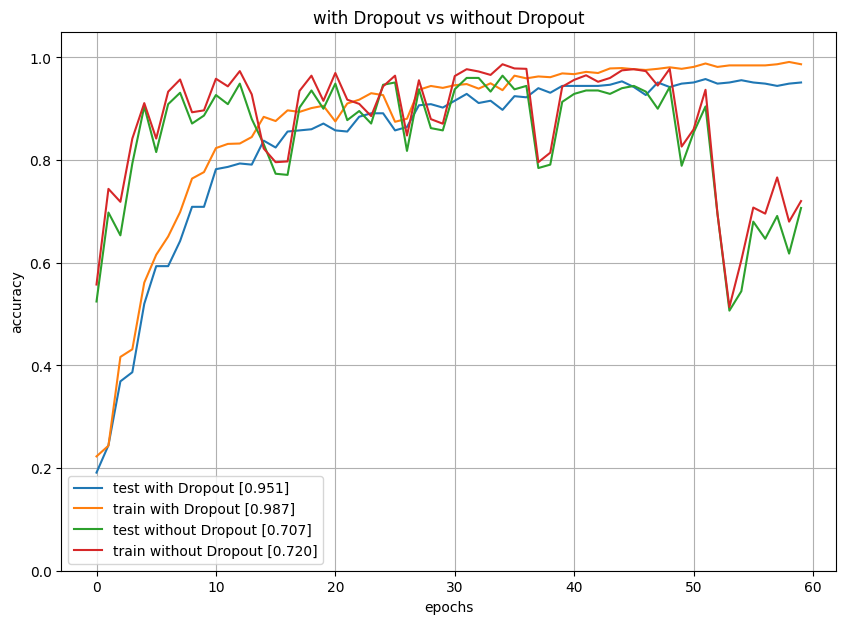

In [84]:
plt.figure(figsize=(10, 7))

plt.plot(best['test_curve'], label=f"test with Dropout [{best['test_accuracy']:.3f}]")
plt.plot(best['train_curve'], label=f"train with Dropout [{best['train_accuracy']:.3f}]")

plt.plot(best_adam['test_curve'], label=f"test without Dropout [{best_adam['test_accuracy']:.3f}]")
plt.plot(best_adam['train_curve'], label=f"train without Dropout [{best_adam['train_accuracy']:.3f}]")

plt.title('with Dropout vs without Dropout')
plt.xlabel('epochs')
plt.ylabel('accuracy')

plt.ylim(0, 1.05)
plt.grid()
plt.legend()

plt.show()

**Выводы:**

Для сети с глубиной 10 слоев обучение без `Dropout` оказалось нестабильным. В течение обучения встречаются резкие скачки вниз по качеству, алгоритм не сходится и не стабилен. Эту проблему хорошо решает регуляризация `Dropout`. С ней Алгоритм намного более стабильный и к 50 эпохе показывает достаточно точный результат и почти перестает меняться.

### `BatchNormalization (1 балл)`

Реализуйте слой `BatchNormalization`. Сравните обучение сети из большого числа слоёв при использовании `BatchNormalization` и без его использования. Сделайте выводы.

In [85]:
class BatchNormalization:
  def __init__(self, num_features, eps=1e-5,momentum=0.9):
    self.eps = eps
    self.momentum = momentum

    self.gamma = np.ones(num_features)
    self.beta = np.zeros(num_features)
    self.params = [self.gamma, self.beta]
    self.running_mean = np.zeros(num_features)
    self.running_var = np.ones(num_features)

    self.training = True

  def forward(self, input):
    if self.training:

      self.input = input
      self.mean = np.mean(input, axis=0)
      self.var = np.var(input, axis=0)

      self.centered = input - self.mean
      self.std_inv = 1 / np.sqrt(self.var + self.eps)
      self.x_hat = self.centered * self.std_inv

      self.running_mean = self.momentum * self.running_mean + (1 - self.momentum) * self.mean
      self.running_var = self.momentum * self.running_var + (1 - self.momentum) * self.var

      return self.gamma * self.x_hat + self.beta

    x_hat = (input - self.running_mean) / np.sqrt(self.running_var + self.eps)
    return self.gamma * x_hat + self.beta

  def backward(self, grad_output):
    batch_size = grad_output.shape[0]

    grad_gamma = np.sum(grad_output * self.x_hat, axis=0)
    grad_beta = np.sum(grad_output, axis=0)
    grad_x_hat = grad_output * self.gamma

    grad_input = (
        self.std_inv / batch_size *
        (batch_size * grad_x_hat - np.sum(grad_x_hat, axis=0)
        - self.x_hat * np.sum(grad_x_hat * self.x_hat, axis=0))
    )

    grad_params = np.r_[grad_gamma.ravel(), grad_beta.ravel()]
    return grad_input, grad_params

  def __repr__(self):
    return f'BatchNormalization({self.gamma.shape[0]})'

In [86]:
def train_mode(network):
  for layer in network:
    if isinstance(layer, (Dropout, BatchNormalization)):
      layer.training = True

def eval_mode(network):
  for layer in network:
    if isinstance(layer, (Dropout, BatchNormalization)):
      layer.training = False

In [87]:
def compute_loss_grad(weights, args):
    network, X, y = args

    set_weights(weights, network)
    train_mode(network)
    activations = forward(network, X)

    loss = NLL(activations, y)
    grad_output = grad_NLL(activations, y)

    all_grads = []
    for layer in reversed(network):
      grad_output, layer_grad = layer.backward(grad_output)
      all_grads.append(layer_grad)

    all_grads.reverse()
    grads = np.r_[tuple(
        grad.ravel()
        for layer_grads in all_grads
        for grad in layer_grads
    )]

    return loss, grads

def predict(network, X):
    eval_mode(network)
    activations = forward(network, X)
    return np.argmax(activations, axis=1)

In [88]:
def make_network(input_size, hidden_layers_size, output_size, n_layers=3,
                 activation_class=ReLU, use_dropout=False, p=0.5, use_batchnorm=False):

    network = []

    for layer_idx in range(n_layers):
        layer_in = input_size if layer_idx == 0 else hidden_layers_size
        layer_out = output_size if layer_idx == n_layers - 1 else hidden_layers_size

        network.append(Dense(layer_in, layer_out))

        if layer_idx != n_layers - 1:
          if use_batchnorm:
            network.append(BatchNormalization(layer_out))
          network.append(activation_class())
          if use_dropout:
            network.append(Dropout(p=p))

    network.append(LogSoftmax())

    return network

In [91]:
network_without_bn = make_network(input_size, hidden_layers_size, output_size,
                                  n_layers=7, use_batchnorm=False)

network_with_bn = make_network(input_size, hidden_layers_size, output_size,
                               n_layers=7, use_batchnorm=True)

In [92]:
initialize_network(network_without_bn, 'Kaiming')
weights = get_weights(network_without_bn)

cb = Callback(network_without_bn, X_train, y_train, X_test, y_test)
res = Adam(compute_loss_grad, weights, args=[network_without_bn, X_train, y_train],
                callback=cb.call, n_iter=40, lr=0.01, batch_size=32)
set_weights(res['x'], network_without_bn)

train_pred = predict(network_without_bn, X_train)
test_pred = predict(network_without_bn, X_test)

train_accuracy = np.mean(train_pred == y_train)
test_accuracy = np.mean(test_pred == y_test)

without_bn = ({'train_accuracy': train_accuracy, 'test_accuracy': test_accuracy,
              'train_curve': cb.train_acc, 'test_curve': cb.test_acc})

In [93]:
initialize_network(network_with_bn, 'Kaiming')
weights = get_weights(network_with_bn)

cb = Callback(network_with_bn, X_train, y_train, X_test, y_test)
res = Adam(compute_loss_grad, weights, args=[network_with_bn, X_train, y_train],
                callback=cb.call, n_iter=40, lr=0.01, batch_size=32)
set_weights(res['x'], network_with_bn)

train_pred = predict(network_with_bn, X_train)
test_pred = predict(network_with_bn, X_test)

train_accuracy = np.mean(train_pred == y_train)
test_accuracy = np.mean(test_pred == y_test)

with_bn = ({'train_accuracy': train_accuracy, 'test_accuracy': test_accuracy,
              'train_curve': cb.train_acc, 'test_curve': cb.test_acc})

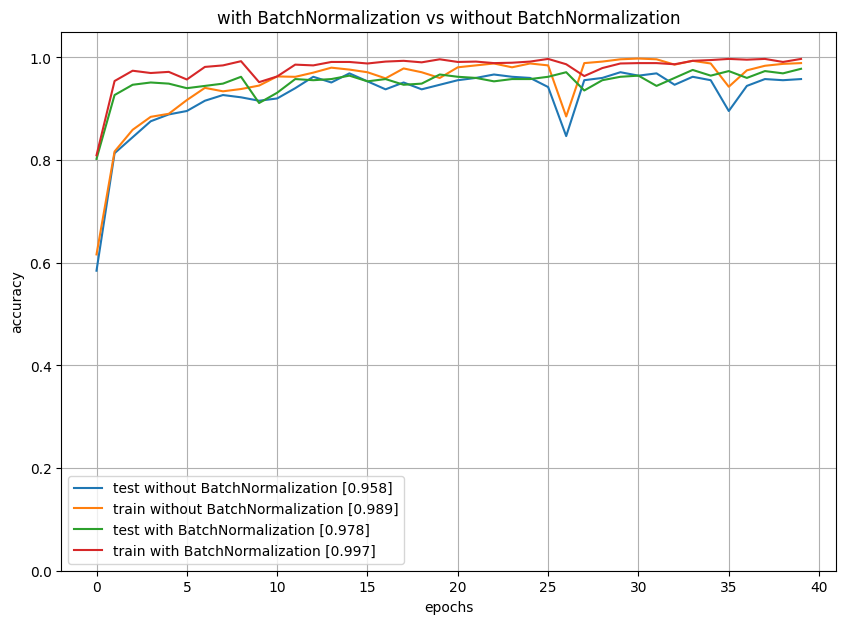

In [94]:
plt.figure(figsize=(10, 7))

plt.plot(without_bn['test_curve'], label=f"test without BatchNormalization [{without_bn['test_accuracy']:.3f}]")
plt.plot(without_bn['train_curve'], label=f"train without BatchNormalization [{without_bn['train_accuracy']:.3f}]")

plt.plot(with_bn['test_curve'], label=f"test with BatchNormalization [{with_bn['test_accuracy']:.3f}]")
plt.plot(with_bn['train_curve'], label=f"train with BatchNormalization [{with_bn['train_accuracy']:.3f}]")

plt.title('with BatchNormalization vs without BatchNormalization')
plt.xlabel('epochs')
plt.ylabel('accuracy')

plt.ylim(0, 1.05)
plt.grid()
plt.legend()

plt.show()

**Выводы:**

При использовании `Batch Normalization` обучение глубокой нейронной сети стало более стабильным. Уже на первых эпохах модель с `Batch Normalization` достигла более высокой точности по сравнению с сетью без нормализации. Итоговая точность на тестовой выборке также увеличилась. `Batch Normalization` помогло избежать скачков качества, которые присутствуют в модели без `Batch Normalization`.